# **EXPLORING JOB DISSATISFACTION IN THE UK USING REDDIT DATA (2022 Dataset)**

## **AN NLP-BASED THEMATIC AND SENTIMENT ANALYSIS**


### **Student Name**: Awopetu Rasheed Oluwadamilare

### **Student Number**: 202432121

### **Library Installation**

In [1]:
pip install praw pandas tqdm python-dotenv emoji vaderSentiment textblob wordcloud pyLDAvis gensim bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 16.1 MB/s eta 0:00:00


In [2]:
pip install spacy

In [3]:
pip install tf-keras

### **Import the necessary libraries**

In [4]:
import pandas as pd
import os, time, json
import praw
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import re, emoji, nltk, spacy
import torch
import warnings
import nltk
warnings.filterwarnings("ignore", category=DeprecationWarning)

from gensim.corpora.dictionary import Dictionary
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap.umap_ import UMAP
from hdbscan import HDBSCAN
from dotenv import load_dotenv
from datetime import datetime, timedelta
from tqdm import tqdm
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from wordcloud import WordCloud
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from nltk.corpus import stopwords
from sklearn.utils.class_weight import compute_class_weight
from sklearn.svm import LinearSVC
from transformers import (AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, Trainer, TrainingArguments)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary
from gensim.models.ldamodel import LdaModel
from collections import Counter
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    classification_report,
    confusion_matrix
)

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


### **Loading Dataset & Data Collection**

##### After filtering the eye.eu Reddit archive for 2022, the result is a cleaned dataset where the posts and comments are separated into two different files.

In [ ]:
Dataframe_Post = pd.read_csv('subreddit_2022_post.csv')

In [ ]:
print("Total Number of Post and row is ", Dataframe_Post.shape)

Total Number of Post and row is  (996, 6)


In [ ]:
Dataframe_Comment = pd.read_csv('subreddit_2022_comment.csv')

In [ ]:
print("Total Number of Post and row is ", Dataframe_Comment.shape)

Total Number of Post and row is  (36138, 6)


### **CSV File combined**

###### Let **combined the 2 datset** together so we can be able to work with a single dataset

In [ ]:
dataset = pd.concat([Dataframe_Post, Dataframe_Comment], ignore_index=True)
print("Combined dataset shape:", dataset.shape)
dataset.head()

Combined dataset shape: (37134, 6)


,id,created_utc,year,subreddit,sentiment,selftext
0,rudclf,1641141388,2022,antiwork,satisfaction,I'm a UK civil servant. I get paid slightly a...
1,ruds1x,1641142598,2022,antiwork,dissatisfaction,"I started this job a few months ago, but it's ..."
2,ruo93e,1641170518,2022,antiwork,dissatisfaction,TLDR - Years ago managers gave terrible justif...
3,rvlkeu,1641270518,2022,antiwork,satisfaction,I am filipino nurse working in the UK. I reall...
4,rvsqvs,1641297487,2022,antiwork,dissatisfaction,Seems like a counter intuitive question for th...


##### Saving the combined dataset so we can use it in our sentiment analysis

In [ ]:
dataset.to_csv('2022_JOB_Dissatisfaction.csv', index=False)

#### **Loading Saved Dataset**

###### We’re importing our dataset from a CSV file and taking a quick look at the top few records to get familiar with the structure of the data before we dive into analysis.

In [ ]:
Dataset = pd.read_csv('2022_JOB_Dissatisfaction.csv')
Dataset.head()

,id,created_utc,year,subreddit,sentiment,selftext
0,rudclf,1641141388,2022,antiwork,satisfaction,I'm a UK civil servant. I get paid slightly a...
1,ruds1x,1641142598,2022,antiwork,dissatisfaction,"I started this job a few months ago, but it's ..."
2,ruo93e,1641170518,2022,antiwork,dissatisfaction,TLDR - Years ago managers gave terrible justif...
3,rvlkeu,1641270518,2022,antiwork,satisfaction,I am filipino nurse working in the UK. I reall...
4,rvsqvs,1641297487,2022,antiwork,dissatisfaction,Seems like a counter intuitive question for th...


### **Data Exploration**

###### Let's examining and understanding our dataset before doing any analysis or modeling.

##### **Displaying basic info of the Dataset**

In [ ]:
print(Dataset.shape)

(37134, 6)


In [ ]:
print(Dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37134 entries, 0 to 37133
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           37134 non-null  object
 1   created_utc  37134 non-null  int64 
 2   year         37134 non-null  int64 
 3   subreddit    37134 non-null  object
 4   sentiment    37134 non-null  object
 5   selftext     37134 non-null  object
dtypes: int64(2), object(4)
memory usage: 1.7+ MB
None


##### **Checking Missing Value**

In [ ]:
print(Dataset.isnull().sum())

id             0
created_utc    0
year           0
subreddit      0
sentiment      0
selftext       0
dtype: int64


###### From the dataset we discover we only have NAN only in the author role and also we have 1 NAN is text_raw. all this will be cleaned during the Data Cleaning Process

##### **Checking for Duplicates**

In [ ]:
print(Dataset.duplicated(subset=['selftext']).sum())

1094


###### We discovered that we have 1,094 Duplicates in our Dataset. We are going to remove all this duplicates during the data cleaning

###### Let check our `label` field that we go from the **Reddit API**  

In [ ]:
Dataset = Dataset.rename(columns={"sentiment": "label"})

In [ ]:
print(Dataset['label'].value_counts())

label
dissatisfaction    33767
satisfaction        3367
Name: count, dtype: int64


###### We clearly discovered that we have 33,767 data that is related to dissatisfaction and 3,367 data that relate to satisfaction.

/tmp/ipython-input-7856422.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=Dataset, palette=["red", "green"])


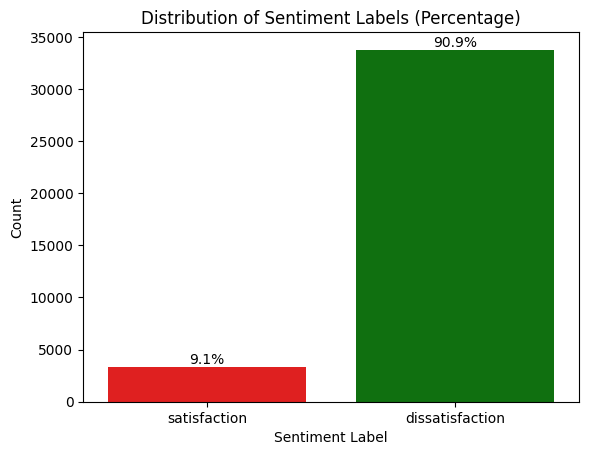

In [ ]:
ax = sns.countplot(x='label', data=Dataset, palette=["red", "green"])

total = len(Dataset)

for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black')

plt.title('Distribution of Sentiment Labels (Percentage)')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.show()

##### Let explore data based on Subreddit

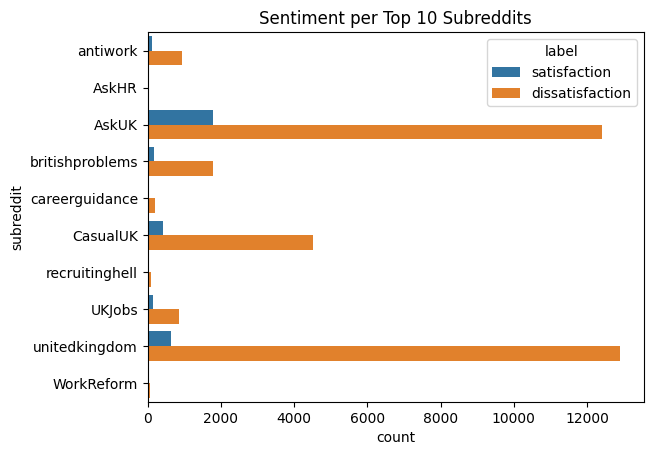

In [ ]:
top_subs = Dataset['subreddit'].value_counts().head(11).index
sns.countplot(y='subreddit', hue='label', data=Dataset[Dataset['subreddit'].isin(top_subs)])
plt.title('Sentiment per Top 10 Subreddits')
plt.show()

###### Let’s find the top subreddits, filter our dataset to include only them, and see how their sentiments compare

In [ ]:
top_subs = Dataset['subreddit'].value_counts().head(11).index
top_data = Dataset[Dataset['subreddit'].isin(top_subs)]
sentiment_table = pd.crosstab(top_data['subreddit'], top_data['label'])
display(sentiment_table)

label,dissatisfaction,satisfaction
subreddit,,
AskHR,38,8
AskUK,12398,1781
CasualUK,4518,413
UKJobs,845,155
WorkReform,65,27
antiwork,922,123
britishproblems,1786,176
careerguidance,210,35
recruitinghell,81,6


###### Let’s find the top subreddits, filter our dataset to include only them, and see how their sentiments compare using the percentage

In [ ]:
top_subs = Dataset['subreddit'].value_counts().head(10).index
top_data = Dataset[Dataset['subreddit'].isin(top_subs)]
sentiment_percent = pd.crosstab(top_data['subreddit'], top_data['label'], normalize='index') * 100
sentiment_percent = sentiment_percent.round(1)
display(sentiment_percent)

label,dissatisfaction,satisfaction
subreddit,,
AskHR,82.6,17.4
AskUK,87.4,12.6
CasualUK,91.6,8.4
UKJobs,84.5,15.5
WorkReform,70.7,29.3
antiwork,88.2,11.8
britishproblems,91.0,9.0
careerguidance,85.7,14.3
recruitinghell,93.1,6.9


###### Let’s create word clouds to visualize what people talk about most comparing positive (satisfaction) and negative (dissatisfaction) words side by side

In [ ]:
Dataset = Dataset.rename(columns={"selftext": "text_raw"})

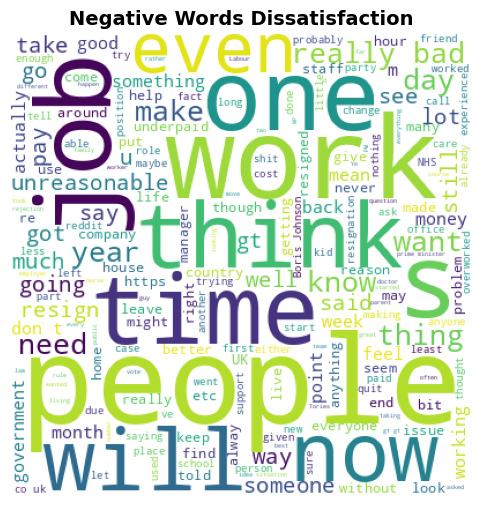

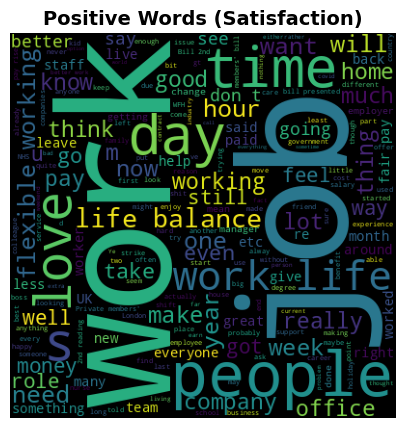

In [ ]:
pos_text = ' '.join(Dataset[Dataset['label']=='satisfaction']['text_raw'])
neg_text = ' '.join(Dataset.loc[Dataset['label'] == 'dissatisfaction', 'text_raw'].dropna().astype(str))

plt.figure(figsize=(6, 6))
plt.imshow(WordCloud(width=400, height=400, background_color='white').generate(neg_text))
plt.title('Negative Words Dissatisfaction', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(WordCloud(width=400, height=400).generate(pos_text))
plt.title('Positive Words (Satisfaction)', fontsize=14, fontweight='bold')
plt.axis('off')

plt.show()

### **Data Cleaning**

###### Removing the column with [Removed] and [Deleted] columns

In [ ]:
print("Row before cleaning:", len(Dataset))

Dataset = Dataset[~Dataset['text_raw'].isin(['[deleted]', '[removed]'])]
Dataset = Dataset[~Dataset['text_raw'].str.lower().str.strip().isin(['[deleted]', '[removed]'])]
Dataset = Dataset.reset_index(drop=True)

print("Remaining rows after cleaning:", len(Dataset))


Row before cleaning: 37134
Remaining rows after cleaning: 37134


###### Drop rows with missing or empty text

In [ ]:
print("Row before dropping missing/empty text:", len(Dataset))

Dataset = Dataset[Dataset['text_raw'].notnull() & (Dataset['text_raw'].str.strip() != '')]

print("Row After dropping missing/empty text:", len(Dataset))

Row before dropping missing/empty text: 37134
Row After dropping missing/empty text: 37134


#### **Removing Duplicates**

In [ ]:
print("Row before removing duplicate:", len(Dataset))

Dataset = Dataset.drop_duplicates(subset=['text_raw'], keep='first')

print("Row After removing duplicate:", len(Dataset))

Row before removing duplicate: 37134
Row After removing duplicate: 36040


###### Now, let’s clean our **text_raw** data by converting everything to lowercase, removing URLs and emojis, filtering out stopwords, and applying lemmatization to make the text neat and consistent!


In [ ]:
nltk.download("stopwords")
EN_STOP = set(stopwords.words("english"))
nlp = spacy.load("en_core_web_sm", exclude=["ner","parser","textcat"])

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower() # lowercase
    text = emoji.replace_emoji(text, replace=" ")   # remove emojis
    text = re.sub(r"http\S+|www\.\S+", " ", text)  # remove URLs
    text = re.sub(r"[^\w\s']", " ", text)          # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()
    return text

def lemmatize(text):
    doc = nlp(text)
    return " ".join(
        tok.lemma_ for tok in doc
        if tok.lemma_ not in EN_STOP and tok.is_alpha
    )

Dataset["text_clean"] = Dataset["text_raw"].apply(clean_text)
Dataset["text_lemma"] = Dataset["text_clean"].apply(lemmatize)

print("Cleaned & lemmatized posts and comments")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Cleaned & lemmatized posts and comments


###### We have successfully cleaned our dataset. Let **Preview** it and move on to the **Sentiment analysis**

In [ ]:
display(Dataset.head())

,id,created_utc,year,subreddit,label,text_raw,text_clean,text_lemma
0,rudclf,1641141388,2022,antiwork,satisfaction,I'm a UK civil servant. I get paid slightly a...,i'm a uk civil servant i get paid slightly abo...,I uk civil servant I get pay slightly average ...
1,ruds1x,1641142598,2022,antiwork,dissatisfaction,"I started this job a few months ago, but it's ...",i started this job a few months ago but it's b...,I start job month ago hell handing resignation...
2,ruo93e,1641170518,2022,antiwork,dissatisfaction,TLDR - Years ago managers gave terrible justif...,tldr years ago managers gave terrible justific...,tldr year ago manager give terrible justificat...
3,rvlkeu,1641270518,2022,antiwork,satisfaction,I am filipino nurse working in the UK. I reall...,i am filipino nurse working in the uk i really...,I filipino nurse work uk I really love job lat...
4,rvsqvs,1641297487,2022,antiwork,dissatisfaction,Seems like a counter intuitive question for th...,seems like a counter intuitive question for th...,seem like counter intuitive question sub unfor...


In [ ]:
Dataset.to_csv('2022_JOB_Dissatisfaction_Cleaned.csv', index=False)

In [ ]:
Dataset = pd.read_csv('2022_JOB_Dissatisfaction_Cleaned.csv')

### **Sentiment Analysis**

##### Sentiment analysis is a natural language processing technique that identifies and classifies emotions or opinions in text as positive, negative, or neutral. It helps organizations understand customer feedback, social media posts, or reviews. Using machine learning, it automates the process of interpreting human emotions for better decision-making and communication.


### **Reddit Label**

###### Let’s rename our sentiment labels for clarity changing *satisfaction* to **Positive** and *dissatisfaction* to **Negative**, then count how many posts fall into each category

In [ ]:
Dataset['label'] = Dataset['label'].replace('dissatisfaction', 'Negative')
Dataset['label'] = Dataset['label'].replace('satisfaction', 'Positive')
Reddit_Label = Dataset["label"].value_counts().sort_index()
print(Reddit_Label)

label
Negative    32810
Positive     3230
Name: count, dtype: int64


###### Let’s visualize the number of posts for each sentiment label with a simple bar chart to see how our data is distributed

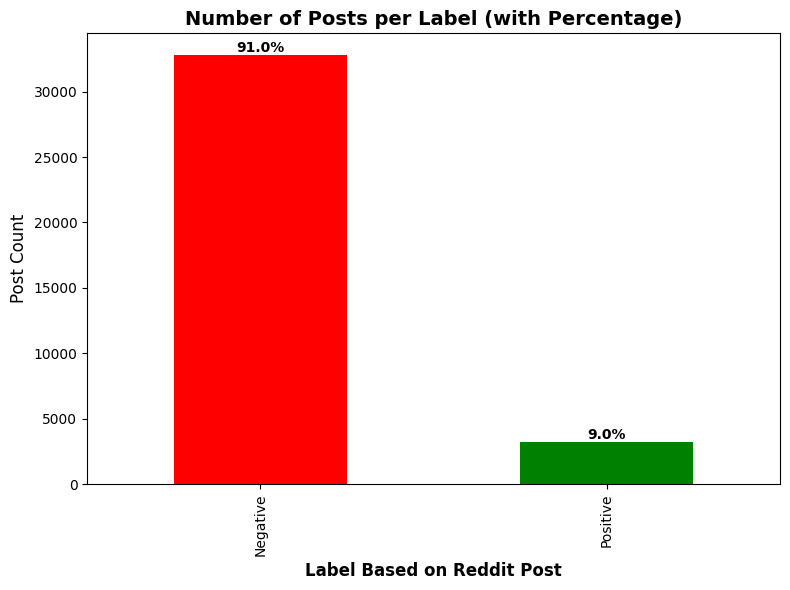

In [ ]:
plt.figure(figsize=(8, 6))
ax = Reddit_Label.plot(kind="bar", color=['red', 'green'])
total = Reddit_Label.sum()
for i, value in enumerate(Reddit_Label):
    percent = 100 * value / total
    ax.text(i, value + 0.5, f'{percent:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title("Number of Posts per Label (with Percentage)", fontsize=14, fontweight='bold')
plt.xlabel("Label Based on Reddit Post", fontsize=12, fontweight="bold")
plt.ylabel("Post Count", fontsize=12)
plt.tight_layout()
plt.show()

#### **Rule Based Using Vader**

###### VADER (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based sentiment analysis tool designed for social media text. It uses a pre-built lexicon and considers word intensity, punctuation, capitalization, and emojis to determine sentiment scores positive, negative, neutral, and compound. Making it accurate for short, informal, and expressive online language.


###### Make a VADER analyzer to check how positive or negative text is

In [ ]:
analyzer = SentimentIntensityAnalyzer()

###### Let’s use the **VADER** sentiment analyzer to score each post’s emotional tone, then classify it as **Positive**, **Negative**, or **Neutral** based on the compound sentiment score.


In [ ]:
Dataset['compound'] = Dataset['text_lemma'].fillna('').apply(lambda x: analyzer.polarity_scores(x)['compound'])

In [ ]:
display(Dataset.head())

,id,created_utc,year,subreddit,label,text_raw,text_clean,text_lemma,compound
0,rudclf,1641141388,2022,antiwork,Positive,I'm a UK civil servant. I get paid slightly a...,i'm a uk civil servant i get paid slightly abo...,I uk civil servant I get pay slightly average ...,0.9105
1,ruds1x,1641142598,2022,antiwork,Negative,"I started this job a few months ago, but it's ...",i started this job a few months ago but it's b...,I start job month ago hell handing resignation...,-0.0258
2,ruo93e,1641170518,2022,antiwork,Negative,TLDR - Years ago managers gave terrible justif...,tldr years ago managers gave terrible justific...,tldr year ago manager give terrible justificat...,0.9976
3,rvlkeu,1641270518,2022,antiwork,Positive,I am filipino nurse working in the UK. I reall...,i am filipino nurse working in the uk i really...,I filipino nurse work uk I really love job lat...,0.9484
4,rvsqvs,1641297487,2022,antiwork,Negative,Seems like a counter intuitive question for th...,seems like a counter intuitive question for th...,seem like counter intuitive question sub unfor...,0.9677


###### We have a new field called compound which was gotten from Vader. Let use the compound score to group their sentiment. According to Vader documentation. positive sentiment: compound score >= 0.05, neutral sentiment: (compound score > -0.05) and (compound score < 0.05), negative sentiment: compound score <= -0.05  

In [ ]:
Dataset['vader_sentiment'] = Dataset['vader_sentiment'] = Dataset['compound'].apply(lambda c: ('Positive' if c >= 0.05 else 'Negative' if c <= -0.05 else 'Neutral'))

###### Now we have sucessfully added the compound score and also a new column called vader sentiment which categorize them into Positive, Negative and Neutral

###### Let plot a bar chart showing how many posts are **Positive**, **Neutral**, or **Negative** according to VADER

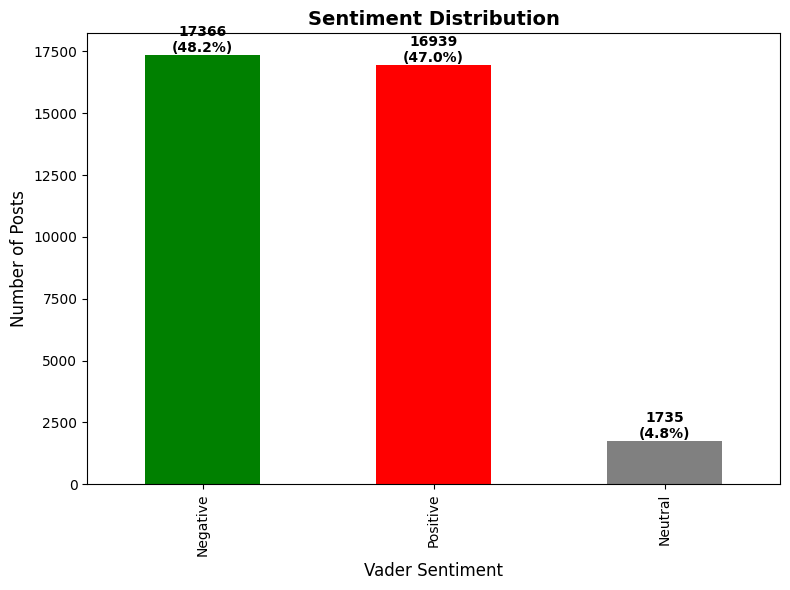

In [ ]:
sentiment_counts_vader = Dataset['vader_sentiment'].value_counts()
total = sentiment_counts_vader.sum()
plt.figure(figsize=(8, 6))
ax = sentiment_counts_vader.plot(kind='bar', color=['green', 'red', 'gray'])
for i, value in enumerate(sentiment_counts_vader):
    percent = 100 * value / total
    ax.text(i, value + 0.5,
            f'{value}\n({percent:.1f}%)',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')

plt.title('Sentiment Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Vader Sentiment', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.tight_layout()
plt.show()

###### let plot an histogram to show how the VADER compound scores are spread across all reviews

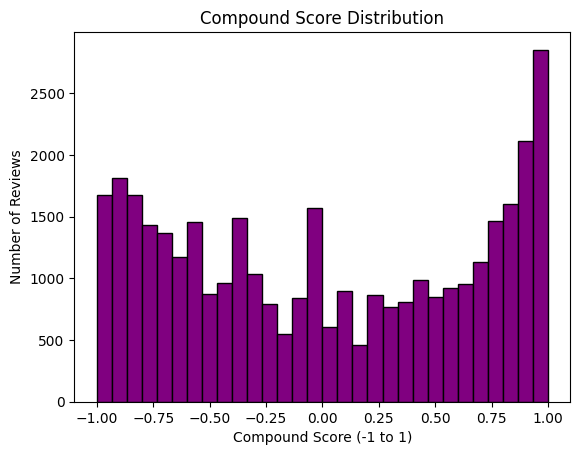

In [ ]:
plt.hist(Dataset['compound'], bins=30, color='purple', edgecolor='black')
plt.title('Compound Score Distribution')
plt.xlabel('Compound Score (-1 to 1)')
plt.ylabel('Number of Reviews')
plt.show()

###### Let create a word cloud of the most common words from positive posts

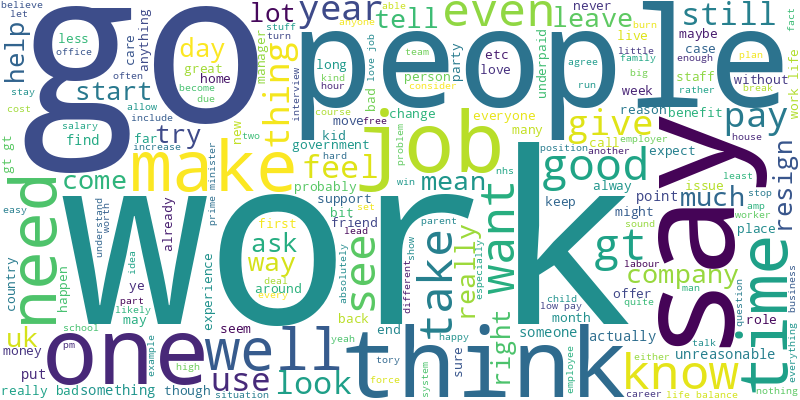

In [ ]:
pos_text = " ".join(Dataset[Dataset['vader_sentiment'] == 'Positive']['text_lemma'])
WordCloud(width=800, height=400, background_color='white').generate(pos_text).to_image()

WordCloud for the Negative word as well

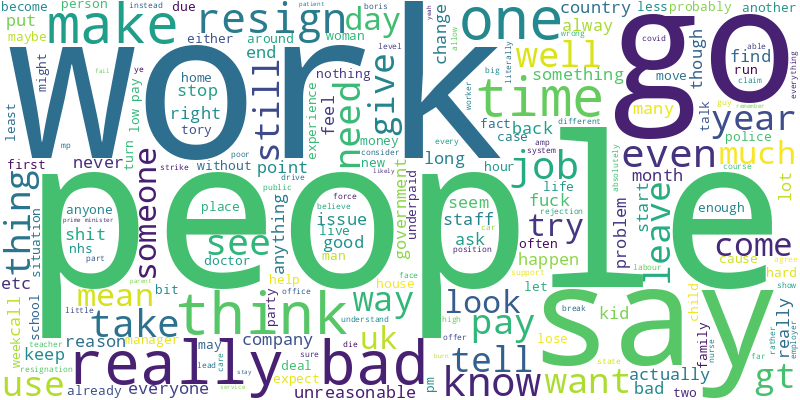

In [ ]:
pos_text = " ".join(Dataset[Dataset['vader_sentiment'] == 'Negative']['text_lemma'])
WordCloud(width=800, height=400, background_color='white').generate(pos_text).to_image()

###### Let print the most positive and most negative reviews based on the highest and lowest VADER compound scores

In [ ]:
print("Most Positive Review:")
print(Dataset.loc[Dataset['compound'].idxmax(), 'text_lemma'])

print("\nMost Negative Review:")
print(Dataset.loc[Dataset['compound'].idxmin(), 'text_lemma'])

Most Positive Review:
gt march prime minister statement coronavirus covid gt gt prime minister boris johnson address nation coronavirus gt march pm letter nation coronavirus gt gt prime minister boris johnson write every uk household urge stay home protect nhs save life eta gt james johnson gt gt gt gt apr gt gt gt gt new jlpartnerspoll today thetime gt gt gt gt ask nationally representative sample british public think boris johnson gt gt gt gt response negative positive word commonly use image gt gt gt word commonly use jpg gt gt gt gt gt gt gt negative total gt gt gt gt right person get brexit need go liar break law need change gt gt gt gt I use think ok resign breach lockdown gt gt gt gt liar untrustworthy gt gt gt gt gt gt gt gt touch criminal gt gt gt gt stupid bad hair liar gt gt gt gt need fire current role pm break many covid rule play part help people bill high cost living gt gt gt gt law breaker liar people gt gt gt gt gt gt gt gt first I really like feel would good country p

#### **Rule Based Using TextBlob**

###### TextBlob is a Python library for processing textual data. It provides simple APIs for tasks like sentiment analysis, part-of-speech tagging, and noun phrase extraction. Using pre-trained models, TextBlob assigns polarity (positive or negative) and subjectivity scores, making it beginner-friendly for quickly analyzing text and building natural language processing applications.


###### Let's download TextBlob's required NLTK corpora (needed for sentiment analysis, translation, etc.)

In [ ]:
!python3 -m textblob.download_corpora

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.


###### Let calculate TextBlob sentiment scores for each text (polarity and subjectivity) and also display the first few rows to check the new columns

In [ ]:
Dataset['polarity'] = Dataset['text_lemma'].fillna('').apply(lambda x: TextBlob(x).sentiment.polarity)
Dataset['subjectivity'] = Dataset['text_lemma'].fillna('').apply(lambda x: TextBlob(x).sentiment.subjectivity)

display(Dataset.head())

,id,created_utc,year,subreddit,label,text_raw,text_clean,text_lemma,compound,vader_sentiment,polarity,subjectivity
0,rudclf,1641141388,2022,antiwork,Positive,I'm a UK civil servant. I get paid slightly a...,i'm a uk civil servant i get paid slightly abo...,I uk civil servant I get pay slightly average ...,0.9105,Positive,0.253750,0.728750
1,ruds1x,1641142598,2022,antiwork,Negative,"I started this job a few months ago, but it's ...",i started this job a few months ago but it's b...,I start job month ago hell handing resignation...,-0.0258,Neutral,-0.012637,0.600824
2,ruo93e,1641170518,2022,antiwork,Negative,TLDR - Years ago managers gave terrible justif...,tldr years ago managers gave terrible justific...,tldr year ago manager give terrible justificat...,0.9976,Positive,0.132401,0.420826
3,rvlkeu,1641270518,2022,antiwork,Positive,I am filipino nurse working in the UK. I reall...,i am filipino nurse working in the uk i really...,I filipino nurse work uk I really love job lat...,0.9484,Positive,-0.033333,0.540000
4,rvsqvs,1641297487,2022,antiwork,Negative,Seems like a counter intuitive question for th...,seems like a counter intuitive question for th...,seem like counter intuitive question sub unfor...,0.9677,Positive,0.032229,0.516667


###### Let's define a function to label TextBlob polarity scores as Positive, Negative, or Neutral

In [ ]:
def label_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

###### Apply the label_sentiment function to classify each TextBlob polarity score as Positive, Negative, or Neutral

In [ ]:
Dataset["Blob_Sentiment"] = Dataset["polarity"].apply(label_sentiment)

###### Let's count how many posts fall into each TextBlob sentiment category (Positive, Negative, Neutral)

In [ ]:
sentiment_counts_blob = Dataset["Blob_Sentiment"].value_counts()

In [ ]:
print(sentiment_counts_blob)

Blob_Sentiment
Positive    19209
Negative    13605
Neutral      3226
Name: count, dtype: int64


###### Let plot a bar chart showing how many reviews are Positive, Neutral, or Negative based on TextBlob sentiment

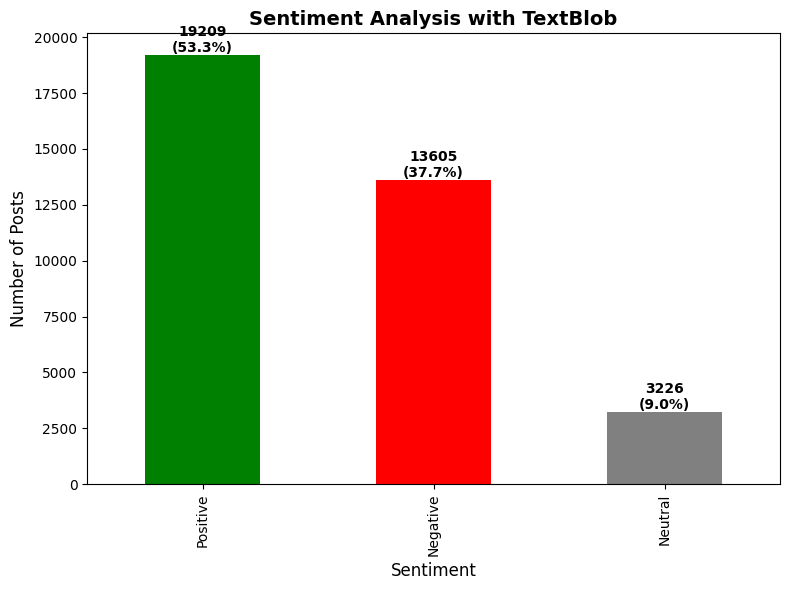

In [ ]:
sentiment_counts = sentiment_counts_blob
total = sentiment_counts.sum()
plt.figure(figsize=(8, 6))
ax = sentiment_counts.plot(kind='bar', color=['green', 'red', 'gray'])
for i, value in enumerate(sentiment_counts):
    percent = 100 * value / total
    ax.text(i, value + 0.5,
            f'{value}\n({percent:.1f}%)',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')

plt.title('Sentiment Analysis with TextBlob', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.tight_layout()
plt.show()

#### **Using Transformer**

##### I loaded a Reddit-trained sentiment model and set up a pipeline to score each text in my dataset. Then I wrote a function that runs the sentiment analysis in batches, picks the highest-scoring label, and adds the sentiment results back into the dataset. Finally, I printed a small preview to check that everything worked.

In [ ]:
MODEL_NAME = "spacesedan/reddit-sentiment-analysis-longformer"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

clf = pipeline(
    task="sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    return_all_scores=True,
    truncation=True,
    max_length=128,
)

def _batch_hf_sentiment(text_series: pd.Series, batch_size: int = 64) -> pd.DataFrame:
    """
    Run HF sentiment in batches over a pandas Series of text and return
    a DataFrame with columns: neg, neu, pos, sentiment (string label).
    """
    text_series = text_series.fillna("").astype(str)

    outputs = clf(list(text_series), batch_size=batch_size)

    rows = []
    for scores in outputs:
        label_to_score = {d["label"].lower(): float(d["score"]) for d in scores}
        top_label = max(label_to_score, key=label_to_score.get)

        rows.append({
            "neg": label_to_score.get("negative"),
            "neu": label_to_score.get("neutral"),
            "pos": label_to_score.get("positive"),
            "sentiment": top_label
        })

    return pd.DataFrame(rows, index=text_series.index)

Dataset_scores = _batch_hf_sentiment(Dataset["text_lemma"])

Dataset = pd.concat([Dataset, Dataset_scores], axis=1)

print(Dataset[["text_lemma", "sentiment"]].head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/958 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/595M [00:00<?, ?B/s]

Device set to use cuda:0
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(
Initializing global attention on CLS token...
Input ids are automatically padded to be a multiple of `config.attention_window`: 512


                                          text_lemma      sentiment
0  I uk civil servant I get pay slightly average ...  very negative
1  I start job month ago hell handing resignation...       positive
2  tldr year ago manager give terrible justificat...       positive
3  I filipino nurse work uk I really love job lat...       positive
4  seem like counter intuitive question sub unfor...  very negative


##### **Visualization for Transformer**

In [ ]:
display(Dataset)

,id,created_utc,year,subreddit,label,text_raw,text_clean,text_lemma,compound,vader_sentiment,polarity,subjectivity,Blob_Sentiment,neg,neu,pos,sentiment
0,rudclf,1641141388,2022,antiwork,Positive,I'm a UK civil servant. I get paid slightly a...,i'm a uk civil servant i get paid slightly abo...,I uk civil servant I get pay slightly average ...,0.9105,Positive,0.253750,0.728750,Positive,0.218057,0.098412,0.134666,very negative
1,ruds1x,1641142598,2022,antiwork,Negative,"I started this job a few months ago, but it's ...",i started this job a few months ago but it's b...,I start job month ago hell handing resignation...,-0.0258,Neutral,-0.012637,0.600824,Negative,0.027224,0.014839,0.680394,positive
2,ruo93e,1641170518,2022,antiwork,Negative,TLDR - Years ago managers gave terrible justif...,tldr years ago managers gave terrible justific...,tldr year ago manager give terrible justificat...,0.9976,Positive,0.132401,0.420826,Positive,0.093591,0.267444,0.345591,positive
3,rvlkeu,1641270518,2022,antiwork,Positive,I am filipino nurse working in the UK. I reall...,i am filipino nurse working in the uk i really...,I filipino nurse work uk I really love job lat...,0.9484,Positive,-0.033333,0.540000,Negative,0.030945,0.012269,0.870931,positive
4,rvsqvs,1641297487,2022,antiwork,Negative,Seems like a counter intuitive question for th...,seems like a counter intuitive question for th...,seem like counter intuitive question sub unfor...,0.9677,Positive,0.032229,0.516667,Positive,0.231623,0.143911,0.064508,very negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36035,ilx6d8q,1661548319,2022,WorkReform,Negative,&gt;Quiet quitting hasn't been mention in any ...,gt quiet quitting hasn't been mention in any o...,gt quiet quitting mention channel I follow wor...,0.6486,Positive,0.019654,0.222857,Positive,0.010554,0.897569,0.006386,neutral
36036,irfcebl,1665163442,2022,WorkReform,Negative,We don't have a free market for most of our he...,we don't have a free market for most of our he...,free market healthcare option exist like retai...,0.9720,Positive,0.001937,0.475244,Positive,0.008491,0.893223,0.005107,neutral
36037,izperip,1670706841,2022,WorkReform,Positive,You seem argumentative for no particular reaso...,you seem argumentative for no particular reaso...,seem argumentative particular reason skirt aro...,0.6415,Positive,0.080769,0.486218,Positive,0.039476,0.164111,0.014907,very negative
36038,izph8c0,1670707857,2022,WorkReform,Positive,&gt; You're skirting around the point that the...,gt you're skirting around the point that the a...,gt skirt around point hypothetical make withou...,0.7592,Positive,0.048196,0.552102,Positive,0.027482,0.429378,0.008840,very negative


###### Because the Transformer we used is 5-point sentiment classification. we need to merge Very positive with postive and very Negative with Negative and plot our chart

In [ ]:
Dataset['sentiment'] = Dataset['sentiment'].replace('negative', 'Negative')
Dataset['sentiment'] = Dataset['sentiment'].replace('positive', 'Positive')
Dataset['sentiment'] = Dataset['sentiment'].replace('neutral', 'Neutral')
Dataset['sentiment'] = Dataset['sentiment'].replace('very negative', 'Negative')
Dataset['sentiment'] = Dataset['sentiment'].replace('very positive', 'Positive')

In [ ]:
Dataset['sentiment'].value_counts()

,count
sentiment,
Neutral,16813
Negative,12597
Positive,6630


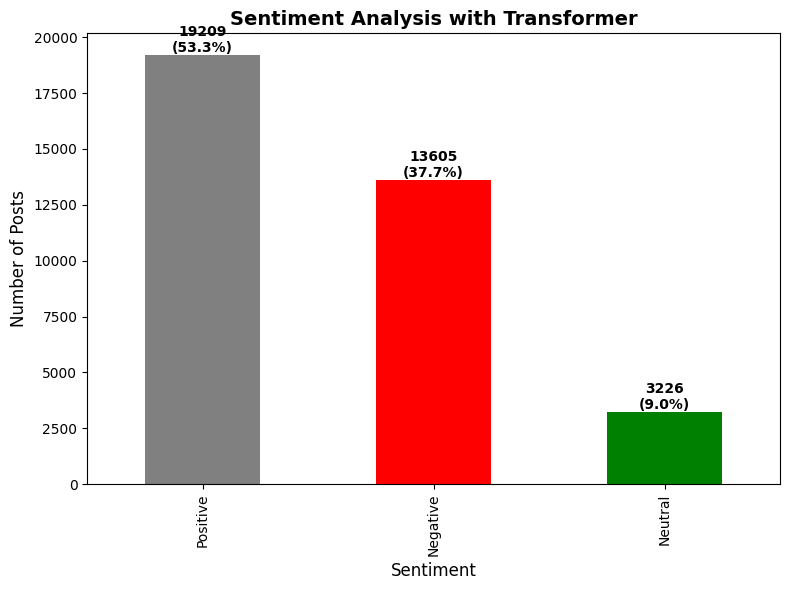

In [ ]:
sentiment_counts_transformer = Dataset['sentiment'].value_counts()
total = sentiment_counts.sum()
plt.figure(figsize=(8, 6))
ax = sentiment_counts.plot(kind='bar', color=['gray', 'red', 'green'])
for i, value in enumerate(sentiment_counts):
    percent = 100 * value / total
    ax.text(i, value + 0.5,
            f'{value}\n({percent:.1f}%)',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')

plt.title('Sentiment Analysis with Transformer', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.tight_layout()
plt.show()

### **Comparison between Vader, TextBlob and Transformer**

###### VADER handles social media text and slang better, while TextBlob is simpler, offering broader NLP features but less accurate on informal language.

###### Let's Compare the number of Positive, Neutral, and Negative sentiments between TextBlob and VADER and also Combine both results into one DataFrame for easy comparison then display them

In [ ]:
textblob_counts = sentiment_counts_blob
vader_counts = sentiment_counts_vader
Transformer_counts = sentiment_counts_transformer

comparison = pd.DataFrame({
    "TextBlob": textblob_counts,
    "VADER": vader_counts,
    "Transformer(twitter-roberta-base-sentiment-latest)": Transformer_counts
})

display(comparison)

,TextBlob,VADER,Transformer(twitter-roberta-base-sentiment-latest)
Negative,13605,17366,12597
Neutral,3226,1735,16813
Positive,19209,16939,6630


###### Plotting a side-by-side bar chart to compare TextBlob and VADER sentiment results.

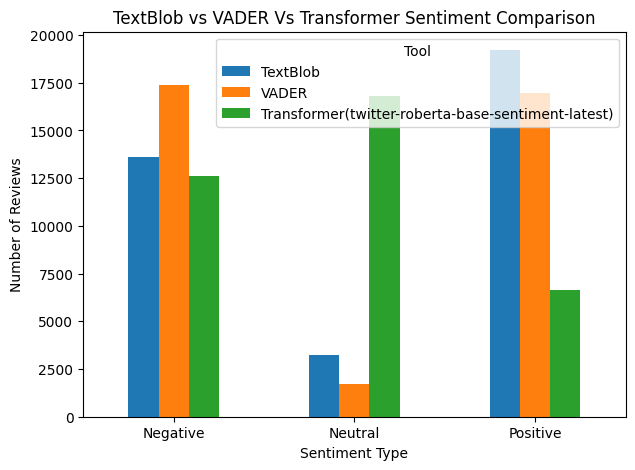

In [ ]:
comparison.plot(kind="bar", figsize=(7,5))
plt.title("TextBlob vs VADER Vs Transformer Sentiment Comparison")
plt.xlabel("Sentiment Type")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.legend(title="Tool")
plt.show()

#### **Model Agreement**

###### Let’s check how consistent our sentiment models are! We’ll see what percentage of samples all four models agree on and how often at least two models share the same sentiment.

In [ ]:
from collections import Counter

Dataset["all_agree"] = (
    (Dataset["vader_sentiment"] == Dataset["Blob_Sentiment"]) &
    (Dataset["vader_sentiment"] == Dataset["sentiment"])
)

all_agree_rate = Dataset['all_agree'].mean()

def majority_agreement(row):
    votes = [row['vader_sentiment'], row['Blob_Sentiment'], row['sentiment']]
    return len(set(votes)) < 2

Dataset['two_or_more_agree'] = Dataset.apply(majority_agreement, axis=1)
two_plus_agree_rate = Dataset['two_or_more_agree'].mean()

print(f"All 4 labelling models agree on {all_agree_rate:.2%} of samples")
print(f"At least two models agree on {two_plus_agree_rate:.2%} of samples")

All 4 labelling models agree on 23.72% of samples
At least two models agree on 23.72% of samples


#### **Average confidence**

###### Let’s evaluate how confident each sentiment model is in its predictions. We calculate absolute confidence scores for **VADER**, **TextBlob**, and the **Transformer model**, then compare their average confidence levels to see which model shows the strongest overall certainty.

In [ ]:
# VADER and TextBlob confidence (absolute values)
Dataset['vader_strength'] = Dataset['compound'].abs()
Dataset['textblob_strength'] = Dataset['polarity'].abs()

# Transformer confidence = highest probability among negative, neutral, positive
Dataset['transformer_strength'] = Dataset[['neg', 'neu', 'pos']].max(axis=1)

# Print average confidence for all three
print("Average VADER confidence:", Dataset['vader_strength'].mean())
print("Average TextBlob confidence:", Dataset['textblob_strength'].mean())
print("Average Transformer confidence:", Dataset['transformer_strength'].mean())

Average VADER confidence: 0.587001231964484
Average TextBlob confidence: 0.1574041763104454
Average Transformer confidence: 0.5156713960710892


###### Let’s visualize the average confidence levels of our three sentiment models — **VADER**, **TextBlob**, and **Transformer** — using a clear bar chart to see which model makes predictions with the most certainty!

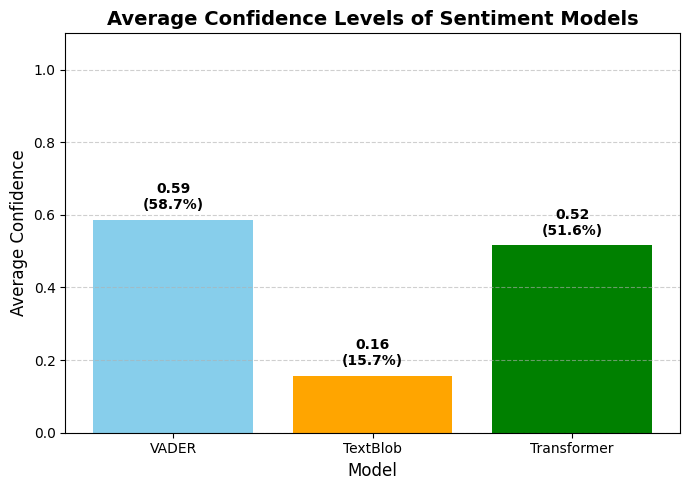

In [ ]:
avg_confidences = {
    'VADER': Dataset['vader_strength'].mean(),
    'TextBlob': Dataset['textblob_strength'].mean(),
    'Transformer': Dataset['transformer_strength'].mean()
}

plt.figure(figsize=(7, 5))
ax = plt.bar(avg_confidences.keys(), avg_confidences.values(),
             color=['skyblue', 'orange', 'green'])

for i, (model, value) in enumerate(avg_confidences.items()):
    percent = value * 100
    plt.text(i, value + 0.02,
             f"{value:.2f}\n({percent:.1f}%)",
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

plt.title("Average Confidence Levels of Sentiment Models", fontsize=14, fontweight='bold')
plt.xlabel("Model", fontsize=12)
plt.ylabel("Average Confidence", fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

###### The comparison of average confidence levels reveals that the Transformer model produces the strongest and most confident sentiment predictions, followed by VADER, while TextBlob shows the weakest overall confidence on the Reddit dataset.

#### **Saving the Sentiment Labelling Dataset**

In [ ]:
Dataset.to_csv('2022_JOB_Dissatisfaction_Sentiment.csv', index=False)

In [ ]:
Dataset = pd.read_csv('2022_JOB_Dissatisfaction_Sentiment.csv')

#### **Traditional Model**

###### We will start by training with traditional model. We are using **Naive Bayes & SVM**

###### Let make a copy of our Dataset

In [ ]:
Dataframe = Dataset.copy()

#### **Naive Bayes**

#### **Naive Bayes Function**

In [ ]:
general_results = []

In [ ]:
Result_global = []

###### So here, we’re building a balanced sentiment model. Basically, we convert our text into **TF-IDF features**, change the sentiment labels into numbers, handle **class imbalance with class weight**, train a **Naive Bayes model**, and then test how accurate it is.

In [ ]:
def train_sentiment_model(dataframe, sentiment_col, use_class_weight=True):
    """
    Train a TF-IDF + MultinomialNB sentiment classifier.
    If use_class_weight=True, compute balanced class weights and pass them
    as per-sample weights to MultinomialNB.fit().
    """

    df = dataframe.copy()

    # Map sentiment labels to numeric values
    label_map = {'Negative': 0, 'Positive': 1, 'Neutral': 2}
    df['label_mapped'] = df[sentiment_col].map(label_map)

    # Drop rows where sentiment is missing or unmapped
    df = df.dropna(subset=['label_mapped'])

    # Clean text_lemma
    df['text_lemma'] = df['text_lemma'].fillna('').astype(str)
    df = df[df['text_lemma'].str.strip() != '']

    # TF-IDF
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    X = tfidf.fit_transform(df['text_lemma'])
    y = df['label_mapped']

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # Compute class weights
    sample_weight_train = None
    if use_class_weight:
        classes = np.unique(y_train)
        weights = compute_class_weight(
            class_weight='balanced',
            classes=classes,
            y=y_train
        )
        class_weight_dict = {c: w for c, w in zip(classes, weights)}

        y_train_series = pd.Series(y_train).reset_index(drop=True)
        sample_weight_train = y_train_series.map(class_weight_dict).to_numpy()

        inv_label_map = {0: 'Negative', 1: 'Positive', 2: 'Neutral'}
        pretty_weights = {
            inv_label_map[c]: round(float(w), 4)
            for c, w in class_weight_dict.items()
        }
        print("Class weights (balanced):", pretty_weights)

    # Train model
    nb = MultinomialNB()
    nb.fit(X_train, y_train, sample_weight=sample_weight_train)

    # Predict
    y_pred = nb.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("F1 Score:", round(f1, 4))

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=['Negative', 'Positive', 'Neutral']
    ))

    print("\nConfusion Matrix (rows=true, cols=pred):")
    print(confusion_matrix(y_test, y_pred))

    model_result = {
        "accuracy": round(float(accuracy), 4),
        "precision": round(float(precision), 4),
        "f1_score": round(float(f1), 4),
        "use_class_weight": use_class_weight,
        "labels": sentiment_col
    }

    general_results.append(model_result)

    return nb, tfidf, accuracy, model_result

###### We’re going to train our sentiment models using the **Naive Bayes** algorithm to compare their performance. The idea is to feed in the sentiment outputs from **VADER**, **TextBlob**, and the **Transformer model** separately, and then check which one gives us the best accuracy and overall results. By doing this, we’ll be able to see which sentiment detection method works best with our dataset and produces the most reliable predictions.


#### **Vader with Naive Bayes**

In [ ]:
Vader_Naive_Bayes = train_sentiment_model(Dataframe, 'vader_sentiment')

Class weights (balanced): {'Negative': 0.6915, 'Positive': 0.7089, 'Neutral': 6.9765}
Accuracy: 0.6822
Precision: 0.7271
F1 Score: 0.7001

Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.72      0.74      3474
    Positive       0.76      0.66      0.71      3388
     Neutral       0.17      0.45      0.25       344

    accuracy                           0.68      7206
   macro avg       0.56      0.61      0.56      7206
weighted avg       0.73      0.68      0.70      7206


Confusion Matrix (rows=true, cols=pred):
[[2508  619  347]
 [ 740 2253  395]
 [  94   95  155]]


#### **Transformer with Naive Bayes**

In [ ]:
Transformer_Naive_Bayes = train_sentiment_model(Dataframe, 'sentiment')

Class weights (balanced): {'Negative': 0.9533, 'Positive': 1.8112, 'Neutral': 0.7148}
Accuracy: 0.6099
Precision: 0.6349
F1 Score: 0.6146

Classification Report:
              precision    recall  f1-score   support

    Negative       0.61      0.53      0.57      2520
    Positive       0.44      0.70      0.54      1326
     Neutral       0.73      0.64      0.68      3360

    accuracy                           0.61      7206
   macro avg       0.59      0.62      0.60      7206
weighted avg       0.63      0.61      0.61      7206


Confusion Matrix (rows=true, cols=pred):
[[1327  602  591]
 [ 193  924  209]
 [ 646  570 2144]]


#### **Text Blob with Naive Bayes**

In [ ]:
TextBlob_Naive_Bayes = train_sentiment_model(Dataframe, 'Blob_Sentiment')

Class weights (balanced): {'Negative': 0.8826, 'Positive': 0.6251, 'Neutral': 3.7395}
Accuracy: 0.7123
Precision: 0.7294
F1 Score: 0.7165

Classification Report:
              precision    recall  f1-score   support

    Negative       0.71      0.68      0.69      2721
    Positive       0.79      0.72      0.75      3842
     Neutral       0.48      0.79      0.59       643

    accuracy                           0.71      7206
   macro avg       0.66      0.73      0.68      7206
weighted avg       0.73      0.71      0.72      7206


Confusion Matrix (rows=true, cols=pred):
[[1849  657  215]
 [ 723 2776  343]
 [  43   92  508]]


##### **Comparing the naive bayes result for the 4 labelling**

###### Let’s visualize how well each sentiment model performed after training with **Naive Bayes** This bar chart compares the accuracy of **VADER**, **TextBlob**, and **Transformer** labelling to see which one delivers the best overall results.

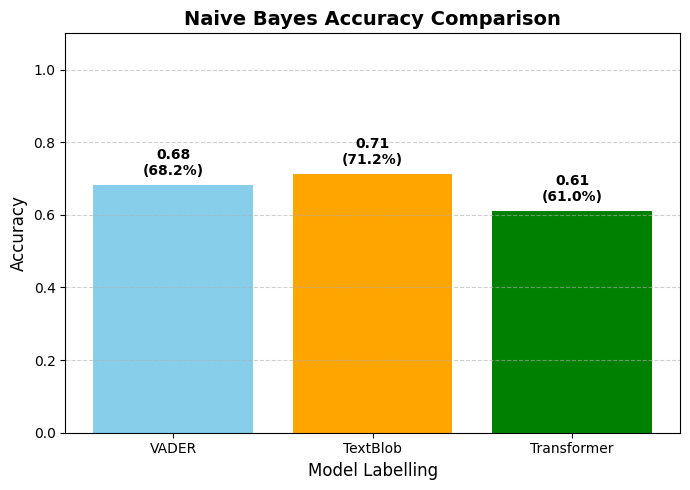

In [ ]:
Naive_Result = {
    'VADER': Vader_Naive_Bayes[2],
    'TextBlob': TextBlob_Naive_Bayes[2],
    'Transformer': Transformer_Naive_Bayes[2]
}

plt.figure(figsize=(7, 5))
ax = plt.bar(Naive_Result.keys(), Naive_Result.values(),
             color=['skyblue', 'orange', 'green'])

for i, (model, value) in enumerate(Naive_Result.items()):
    percent = value * 100
    plt.text(i, value + 0.02,
             f"{value:.2f}\n({percent:.1f}%)",  # shows both
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

plt.title("Naive Bayes Accuracy Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Model Labelling", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

###### Let’s neatly display our Naive Bayes accuracy results in a table using a DataFrame, so we can easily compare **VADER**, **TextBlob**, and **Transformer** model performances side by side.

In [ ]:
result_naive = pd.DataFrame(Naive_Result, index=[0])
display(result_naive)

,VADER,TextBlob,Transformer
0,0.682209,0.712323,0.609908


In [ ]:
print(general_results)

[{'accuracy': 0.6822, 'precision': 0.7271, 'f1_score': 0.7001, 'use_class_weight': True, 'labels': 'vader_sentiment'}, {'accuracy': 0.6099, 'precision': 0.6349, 'f1_score': 0.6146, 'use_class_weight': True, 'labels': 'sentiment'}, {'accuracy': 0.7123, 'precision': 0.7294, 'f1_score': 0.7165, 'use_class_weight': True, 'labels': 'Blob_Sentiment'}]


In [ ]:
data = {
    "Naive Bayes": general_results
}

Result_global.append(data)

##### **SVM (Support Vector Machine)**

###### We’re now training a sentiment model using **Support Vector Machine (LinearSVC)** instead of Naive Bayes. We map the labels, turn the cleaned text into TF-IDF features, split the data, train the SVM with class balancing, and then check accuracy, report, and confusion matrix.

In [ ]:
general_results = []

In [ ]:
def train_svm_sentiment_model(dataframe, sentiment_col):
    """
    Train a TF-IDF + LinearSVC sentiment classifier
    for labels: Negative, Positive, Neutral.

    Also computes accuracy, precision, and F1-score (weighted),
    stores them in a result object, and appends it to the global
    general_results list.
    """

    df = dataframe.copy()

    # Map sentiment labels to numeric values
    label_map = {'Negative': 0, 'Positive': 1, 'Neutral': 2}
    df['label_mapped'] = df[sentiment_col].map(label_map)

    # Drop rows where sentiment is missing or unmapped
    df = df.dropna(subset=['label_mapped'])

    # Clean text_lemma: replace NaN/None with "", ensure string
    df['text_lemma'] = df['text_lemma'].fillna('').astype(str)

    # Drop completely empty texts
    df = df[df['text_lemma'].str.strip() != '']

    # Text → TF-IDF features
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    X = tfidf.fit_transform(df['text_lemma'])
    y = df['label_mapped'].astype(int)

    # Train/test split (stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # Train Linear SVM with balanced class weights
    svm = LinearSVC(class_weight='balanced', random_state=42)
    svm.fit(X_train, y_train)

    # Predict & evaluate
    y_pred = svm.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    print("Accuracy:", round(accuracy, 4))
    print("Precision (weighted):", round(precision, 4))
    print("F1 Score (weighted):", round(f1, 4))

    print("\nClassification Report:")
    target_names = ['Negative', 'Positive', 'Neutral']
    print(classification_report(y_test, y_pred, target_names=target_names))

    print("\nConfusion Matrix (rows=true, cols=pred):")
    print(confusion_matrix(y_test, y_pred))

    scores_array = [
        round(float(precision), 4),
        round(float(accuracy), 4),
        round(float(f1), 4)
    ]

    model_result = {
        "model_name": "LinearSVC",
        "use_class_weight": True,
        "scores": scores_array,
        "labels": sentiment_col
    }

    general_results.append(model_result)

    return svm, tfidf, accuracy, model_result

#### **Vader with SVM**

In [ ]:
Vader_SVM = train_svm_sentiment_model(Dataframe, 'vader_sentiment')

Accuracy: 0.8422
Precision (weighted): 0.8495
F1 Score (weighted): 0.8456

Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.87      0.87      3474
    Positive       0.88      0.86      0.87      3388
     Neutral       0.31      0.39      0.34       344

    accuracy                           0.84      7206
   macro avg       0.69      0.71      0.70      7206
weighted avg       0.85      0.84      0.85      7206


Confusion Matrix (rows=true, cols=pred):
[[3024  302  148]
 [ 323 2911  154]
 [ 111   99  134]]


#### **Transformer with SVM**

In [ ]:
Transformer_SVM = train_svm_sentiment_model(Dataframe, 'sentiment')

Accuracy: 0.744
Precision (weighted): 0.7431
F1 Score (weighted): 0.7428

Classification Report:
              precision    recall  f1-score   support

    Negative       0.70      0.67      0.69      2520
    Positive       0.77      0.71      0.74      1326
     Neutral       0.76      0.81      0.79      3360

    accuracy                           0.74      7206
   macro avg       0.74      0.73      0.74      7206
weighted avg       0.74      0.74      0.74      7206


Confusion Matrix (rows=true, cols=pred):
[[1695  168  657]
 [ 197  938  191]
 [ 516  116 2728]]


#### **Text Blob with SVM**

In [ ]:
TextBlob_SVM = train_svm_sentiment_model(Dataframe, 'Blob_Sentiment')

Accuracy: 0.8832
Precision (weighted): 0.8849
F1 Score (weighted): 0.8836

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87      2721
    Positive       0.91      0.90      0.90      3842
     Neutral       0.76      0.88      0.81       643

    accuracy                           0.88      7206
   macro avg       0.85      0.88      0.86      7206
weighted avg       0.88      0.88      0.88      7206


Confusion Matrix (rows=true, cols=pred):
[[2342  309   70]
 [ 275 3459  108]
 [  36   44  563]]


#### **Comparing the 4 result for SVM**

###### Let’s visualize how each sentiment model performed when trained with **SVM**! This bar chart compares the accuracy of **VADER**, **TextBlob**, and **Transformer** labelling, helping us see which one delivers the highest performance with the SVM classifier.


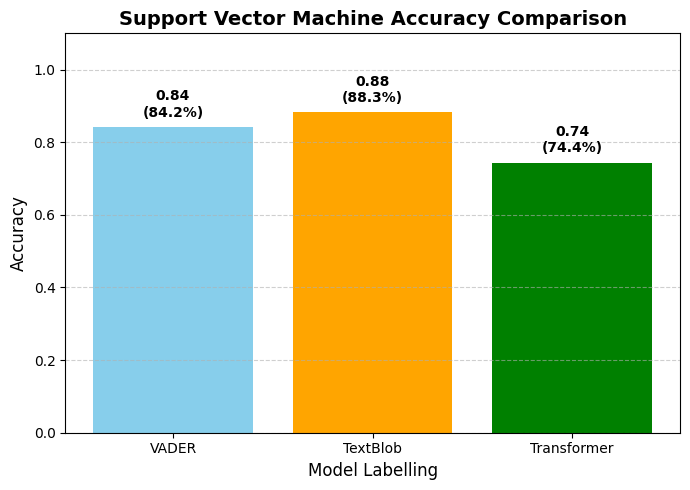

In [ ]:
SVM_Result = {
    'VADER': Vader_SVM[2],
    'TextBlob': TextBlob_SVM[2],
    'Transformer': Transformer_SVM[2]
}

plt.figure(figsize=(7, 5))
ax = plt.bar(SVM_Result.keys(), SVM_Result.values(),
             color=['skyblue', 'orange', 'green'])

for i, (model, value) in enumerate(SVM_Result.items()):
    percent = value * 100
    plt.text(i, value + 0.02,
             f"{value:.2f}\n({percent:.1f}%)",  # shows both
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

plt.title("Support Vector Machine Accuracy Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Model Labelling", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
result_svm = pd.DataFrame(SVM_Result, index=[0])
display(result_svm)

,VADER,TextBlob,Transformer
0,0.842215,0.883153,0.743963


In [ ]:
data = {
    "SVM": general_results
}

Result_global.append(data)

In [ ]:
display(Result_global)

[{'Naive Bayes': [{'accuracy': 0.6822,
    'precision': 0.7271,
    'f1_score': 0.7001,
    'use_class_weight': True,
    'labels': 'vader_sentiment'},
   {'accuracy': 0.6099,
    'precision': 0.6349,
    'f1_score': 0.6146,
    'use_class_weight': True,
    'labels': 'sentiment'},
   {'accuracy': 0.7123,
    'precision': 0.7294,
    'f1_score': 0.7165,
    'use_class_weight': True,
    'labels': 'Blob_Sentiment'}]},
 {'SVM': [{'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.8495, 0.8422, 0.8456],
    'labels': 'vader_sentiment'},
   {'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.7431, 0.744, 0.7428],
    'labels': 'sentiment'},
   {'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.8849, 0.8832, 0.8836],
    'labels': 'Blob_Sentiment'}]}]

### **Deep Learning Model**

###### We’re going to build two deep learning models **BERT** and a **CNN for text** to train and compare performance across the **VADER**, **TextBlob**, and **Transformer** sentiment datasets.

###### Let make the copy of the dataset

In [ ]:
df = Dataset.copy()

#### **CNN for Text**

###### We’re training a **CNN-based deep learning model** for sentiment analysis. The text is tokenized, padded, and converted into embeddings so the model can learn meaningful word patterns. Using convolutional and dense layers, it classifies posts as **Positive**, **Negative**, or **Neutral**, while class weights ensure balanced learning and accurate evaluation results.

In [ ]:
general_results = []

In [ ]:
def train_cnn_sentiment_model(
    dataframe, sentiment_col, max_words=10000, max_len=200,
    embedding_dim=100, epochs=5, batch_size=64
):
    df = dataframe.copy()

    # Map sentiment labels to numeric values
    label_map = {'Negative': 0, 'Positive': 1, 'Neutral': 2}
    df['label_mapped'] = df[sentiment_col].map(label_map)

    # Drop rows where sentiment is missing or unmapped
    df = df.dropna(subset=['label_mapped'])

    # Clean text_lemma
    df['text_lemma'] = df['text_lemma'].fillna('').astype(str)
    df = df[df['text_lemma'].str.strip() != '']

    y = df['label_mapped'].values

    # Tokenize text data
    tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
    tokenizer.fit_on_texts(df['text_lemma'])
    sequences = tokenizer.texts_to_sequences(df['text_lemma'])
    X = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # Compute class weights
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
    print("\nClass Weights:", class_weight_dict)

    # Build CNN model
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
        Conv1D(128, 5, activation='relu'),
        GlobalMaxPooling1D(),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dense(3, activation='softmax')  # 3 classes: Negative, Positive, Neutral
    ])

    # Compile model
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    # Train model with class weights
    history = model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weight_dict,
        verbose=1
    )

    # Evaluate model
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    print("\nAccuracy:", round(accuracy, 4))
    print("Precision (weighted):", round(precision, 4))
    print("F1 Score (weighted):", round(f1, 4))

    print("\nClassification Report:")
    target_names = ['Negative', 'Positive', 'Neutral']
    print(classification_report(y_test, y_pred, target_names=target_names))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Build scores array [precision, accuracy, f1]
    scores_array = [
        round(float(precision), 4),
        round(float(accuracy), 4),
        round(float(f1), 4)
    ]

    # Build result object
    model_result = {
        "model_name": "CNN",
        "use_class_weight": True,
        "scores": scores_array,
        "labels": sentiment_col
    }

    general_results.append(model_result)

    return model, tokenizer, accuracy, model_result

In [ ]:
print("NaNs in text_lemma:", df['text_lemma'].isna().sum())
print("Types in text_lemma:", df['text_lemma'].apply(type).value_counts())

NaNs in text_lemma: 14
Types in text_lemma: text_lemma
<class 'str'>      36026
<class 'float'>       14
Name: count, dtype: int64


In [ ]:
df['text_lemma'] = df['text_lemma'].fillna('')

df = df[~df['text_lemma'].apply(lambda x: isinstance(x, float))]

df['text_lemma'] = df['text_lemma'].astype(str)

print("NaNs in text_lemma:", df['text_lemma'].isna().sum())
print("Types in text_lemma:", df['text_lemma'].apply(type).value_counts())

NaNs in text_lemma: 0
Types in text_lemma: text_lemma
<class 'str'>    36040
Name: count, dtype: int64


#### **CNN with Vader Sentiment**

In [ ]:
Vader_CNN = train_cnn_sentiment_model(df, 'vader_sentiment')


Class Weights: {0: np.float64(0.6915250983779634), 1: np.float64(0.7089267704720439), 2: np.float64(6.976519002662793)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.5148 - loss: 0.9984 - val_accuracy: 0.7897 - val_loss: 0.5653
Epoch 2/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7655 - loss: 0.6527 - val_accuracy: 0.7686 - val_loss: 0.6163
Epoch 3/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8228 - loss: 0.4851 - val_accuracy: 0.7949 - val_loss: 0.5355
Epoch 4/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8776 - loss: 0.3216 - val_accuracy: 0.7887 - val_loss: 0.5559
Epoch 5/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9093 - loss: 0.2248 - val_accuracy: 0.7849 - val_loss: 0.5932
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

Accuracy: 0.7928
Precision (weighted): 0.8042
F1 Score (weighted): 0.7977

Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.80      0.82      3474
    Positive       0.82      0.82      0.82      3388
     Neutral       0.31      0.44      0.36       344

    a

#### **CNN with Transformer**

In [ ]:
Transformer_CNN = train_cnn_sentiment_model(df, 'sentiment')


Class Weights: {0: np.float64(0.9533260560351957), 1: np.float64(1.8112116641528406), 2: np.float64(0.7148349331547487)}
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


406/406 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5093 - loss: 0.9439 - val_accuracy: 0.7647 - val_loss: 0.5658
Epoch 2/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7808 - loss: 0.5318 - val_accuracy: 0.7710 - val_loss: 0.5361
Epoch 3/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8464 - loss: 0.3805 - val_accuracy: 0.7724 - val_loss: 0.5314
Epoch 4/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8971 - loss: 0.2676 - val_accuracy: 0.7779 - val_loss: 0.5842
Epoch 5/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9328 - loss: 0.1824 - val_accuracy: 0.7717 - val_loss: 0.6488
226/226 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Accuracy: 0.7587
Precision (weighted): 0.7592
F1 Score (weighted): 0.7587

Classification Report:
              precision    recall  f1-score   support

    Negative       0.70      0.70      0.70      2520
    Positive       0.75      0.81      0.78      1326
     Neutral       0.81      0.78      0.79      3360

    accuracy    

#### **CNN with Text Blob**

In [ ]:
TextBlob_CNN = train_cnn_sentiment_model(df, 'Blob_Sentiment')


Class Weights: {0: np.float64(0.8826411858385398), 1: np.float64(0.625149129086137), 2: np.float64(3.7394576359154015)}
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


406/406 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5829 - loss: 0.8047 - val_accuracy: 0.8185 - val_loss: 0.4352
Epoch 2/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8357 - loss: 0.3300 - val_accuracy: 0.8525 - val_loss: 0.3537
Epoch 3/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8930 - loss: 0.2297 - val_accuracy: 0.8515 - val_loss: 0.3575
Epoch 4/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9329 - loss: 0.1460 - val_accuracy: 0.8432 - val_loss: 0.3991
Epoch 5/5
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9541 - loss: 0.0981 - val_accuracy: 0.8466 - val_loss: 0.4318
226/226 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Accuracy: 0.8636
Precision (weighted): 0.8634
F1 Score (weighted): 0.8634

Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.83      0.83      2721
    Positive       0.87      0.89      0.88      3842
     Neutral       0.89      0.86      0.88       643

    accuracy    

#### **Comparison of the 4 for CNN**

###### Let’s visualize how well our **CNN models** performed! This bar chart compares the accuracy of **VADER**, **TextBlob**, and **Transformer** sentiment labelling, with percentage values displayed on each bar to clearly show which model achieved the best performance.

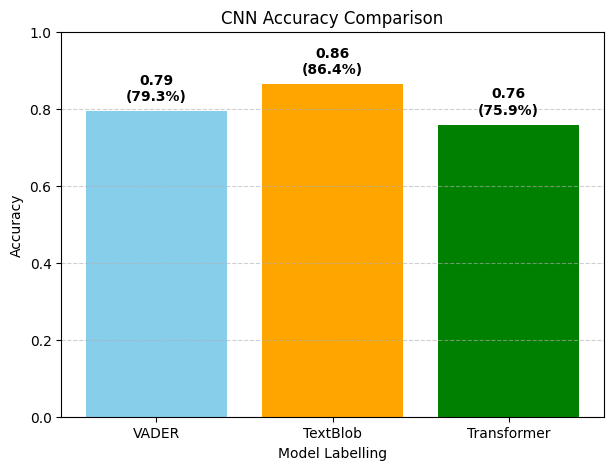

In [ ]:
CNN_Result = {
    'VADER': Vader_CNN[2],
    'TextBlob': TextBlob_CNN[2],
    'Transformer': Transformer_CNN[2],
}

plt.figure(figsize=(7,5))
ax = plt.bar(CNN_Result.keys(), CNN_Result.values(),
             color=['skyblue', 'orange', 'green'])

for i, (model, value) in enumerate(CNN_Result.items()):
    percent = value * 100
    plt.text(i, value + 0.02,
             f"{value:.2f}\n({percent:.1f}%)",  # shows both
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')


plt.bar(CNN_Result.keys(), CNN_Result.values(), color=['skyblue','orange','green'])
plt.title("CNN Accuracy Comparison")
plt.xlabel("Model Labelling")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

###### Let’s display the **CNN model results** in a clean table using a DataFrame. This makes it easy to compare the accuracies of **VADER**, **TextBlob**, and **Transformer** sentiment models side by side and identify which one performed best.

In [ ]:
result_CNN = pd.DataFrame(CNN_Result, index=[0])
display(result_CNN)

,VADER,TextBlob,Transformer
0,0.792812,0.863586,0.758673


In [ ]:
data = {
    "CNN": general_results
}

Result_global.append(data)

In [ ]:
display(Result_global)

[{'Naive Bayes': [{'accuracy': 0.6822,
    'precision': 0.7271,
    'f1_score': 0.7001,
    'use_class_weight': True,
    'labels': 'vader_sentiment'},
   {'accuracy': 0.6099,
    'precision': 0.6349,
    'f1_score': 0.6146,
    'use_class_weight': True,
    'labels': 'sentiment'},
   {'accuracy': 0.7123,
    'precision': 0.7294,
    'f1_score': 0.7165,
    'use_class_weight': True,
    'labels': 'Blob_Sentiment'}]},
 {'SVM': [{'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.8495, 0.8422, 0.8456],
    'labels': 'vader_sentiment'},
   {'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.7431, 0.744, 0.7428],
    'labels': 'sentiment'},
   {'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.8849, 0.8832, 0.8836],
    'labels': 'Blob_Sentiment'}]},
 {'CNN': [{'model_name': 'CNN',
    'use_class_weight': True,
    'scores': [0.8042, 0.7928, 0.7977],
    'labels': 'vader_sentiment'},
   {'model_name': 'CNN',
    'use_cla

#### **Using Transformer BERT**

###### We’re fine-tuning a BERT model for sentiment analysis. We take the cleaned text, map each sentiment (Negative, Positive, Neutral) to numbers, split into train/test, tokenize with a pretrained BERT tokenizer, and train a sequence classification model. After training, we measure performance using accuracy, a classification report, and a confusion matrix.

In [ ]:
general_results = []

In [ ]:
class _SimpleDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(int(self.labels[idx]))
        return item


def train_bert_sentiment_model(
    dataframe,
    sentiment_col,
    text_col="text_lemma",
    model_name="bert-base-uncased",
    max_len=128,
    epochs=2,
    batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    random_state=42
):
    # Map labels
    label_map = {"Negative": 0, "Positive": 1, "Neutral": 2}
    df = dataframe[[text_col, sentiment_col]].dropna().copy()
    df["label_mapped"] = df[sentiment_col].map(label_map)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        df[text_col].tolist(),
        df["label_mapped"].tolist(),
        test_size=0.2,
        stratify=df["label_mapped"],
        random_state=random_state
    )

    # Tokenizer & encodings
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    train_enc = tokenizer(
        X_train, truncation=True, padding=False, max_length=max_len
    )
    test_enc = tokenizer(
        X_test, truncation=True, padding=False, max_length=max_len
    )

    train_ds = _SimpleDataset(train_enc, y_train)
    test_ds = _SimpleDataset(test_enc, y_test)

    # Model
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=3
    )

    collator = DataCollatorWithPadding(tokenizer=tokenizer)
    args = TrainingArguments(
        output_dir="bert_sentiment_outputs",
        eval_strategy="epoch",
        save_strategy="no",
        logging_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=weight_decay,
        report_to=[]
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        tokenizer=tokenizer,
        data_collator=collator,
    )

    # Train
    trainer.train()

    # Predict
    preds = trainer.predict(test_ds)
    y_pred = np.argmax(preds.predictions, axis=1)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    print("\nAccuracy:", round(accuracy, 4))
    print("Precision (weighted):", round(precision, 4))
    print("F1 Score (weighted):", round(f1, 4))

    print("\nClassification Report:")
    target_names = ["Negative", "Positive", "Neutral"]
    print(classification_report(y_test, y_pred, target_names=target_names))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    scores_array = [
        round(float(precision), 4),
        round(float(accuracy), 4),
        round(float(f1), 4)
    ]

    model_result = {
        "model_name": f"BERT ({model_name})",
        "use_class_weight": False,
        "scores": scores_array,
        "labels": sentiment_col
    }

    # Push into global results
    general_results.append(model_result)

    return model, tokenizer, trainer, accuracy, model_result

#### **Transformer with Vader**

In [ ]:
Vader_BERT = train_bert_sentiment_model(df, 'vader_sentiment', model_name="distilbert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1217991567.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,0.456800,0.336636
2,0.262900,0.316595



Accuracy: 0.8944
Precision (weighted): 0.8926
F1 Score (weighted): 0.89

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.92      0.91      3473
    Positive       0.90      0.91      0.91      3388
     Neutral       0.82      0.41      0.54       347

    accuracy                           0.89      7208
   macro avg       0.87      0.75      0.79      7208
weighted avg       0.89      0.89      0.89      7208


Confusion Matrix:
[[3208  250   15]
 [ 274 3098   16]
 [ 103  103  141]]


#### **Transformer with Transformer**

In [ ]:
Transformer_BERT = train_bert_sentiment_model(df, 'sentiment')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1217991567.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,0.498300,0.367530
2,0.279200,0.382964



Accuracy: 0.8596
Precision (weighted): 0.8623
F1 Score (weighted): 0.8602

Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.85      0.83      2519
    Positive       0.84      0.89      0.86      1326
     Neutral       0.91      0.85      0.88      3363

    accuracy                           0.86      7208
   macro avg       0.85      0.87      0.86      7208
weighted avg       0.86      0.86      0.86      7208


Confusion Matrix:
[[2148  133  238]
 [ 103 1180   43]
 [ 398   97 2868]]


#### **Transformer with Transformer**

In [ ]:
TextBlob_BERT = train_bert_sentiment_model(df, 'Blob_Sentiment')

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1217991567.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,0.425200,0.261532
2,0.210500,0.256185



Accuracy: 0.9165
Precision (weighted): 0.9178
F1 Score (weighted): 0.9168

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.92      0.90      2721
    Positive       0.94      0.92      0.93      3842
     Neutral       0.94      0.90      0.92       645

    accuracy                           0.92      7208
   macro avg       0.92      0.91      0.92      7208
weighted avg       0.92      0.92      0.92      7208


Confusion Matrix:
[[2506  194   21]
 [ 307 3521   14]
 [  47   19  579]]


#### **Comparison of the 3 for BERT**

###### Let’s visualize how well our **BERT models** performed across different sentiment labelling methods **VADER**, **TextBlob**, and **Transformer**. This bar chart compares their accuracy to reveal which dataset helped BERT achieve the best performance and most reliable predictions.


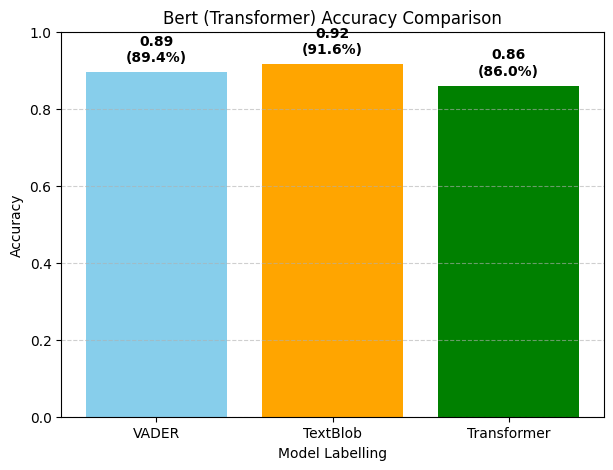

In [ ]:
BERT_Result = {
    'VADER': Vader_BERT[3],
    'TextBlob': TextBlob_BERT[3],
    'Transformer': Transformer_BERT[3]
}
plt.figure(figsize=(7,5))
ax = plt.bar(BERT_Result.keys(), BERT_Result.values(),
             color=['skyblue', 'orange', 'green'])

for i, (model, value) in enumerate(BERT_Result.items()):
    percent = value * 100
    plt.text(i, value + 0.02,
             f"{value:.2f}\n({percent:.1f}%)",  # shows both
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')


plt.bar(BERT_Result.keys(), BERT_Result.values(), color=['skyblue','orange','green'])
plt.title("Bert (Transformer) Accuracy Comparison")
plt.xlabel("Model Labelling")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

###### Let’s neatly display our **BERT model results** in a table using a DataFrame. This makes it easy to compare the accuracy of **VADER**, **TextBlob**, and **Transformer** labelling side by side and identify which one produced the best overall performance.

In [ ]:
result_bert = pd.DataFrame(BERT_Result, index=[0])
display(result_bert)

,VADER,TextBlob,Transformer
0,0.894423,0.916482,0.8596


In [ ]:
data = {
    "Transformer": general_results
}

Result_global.append(data)

In [ ]:
display(Result_global)

[{'Naive Bayes': [{'accuracy': 0.6822,
    'precision': 0.7271,
    'f1_score': 0.7001,
    'use_class_weight': True,
    'labels': 'vader_sentiment'},
   {'accuracy': 0.6099,
    'precision': 0.6349,
    'f1_score': 0.6146,
    'use_class_weight': True,
    'labels': 'sentiment'},
   {'accuracy': 0.7123,
    'precision': 0.7294,
    'f1_score': 0.7165,
    'use_class_weight': True,
    'labels': 'Blob_Sentiment'}]},
 {'SVM': [{'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.8495, 0.8422, 0.8456],
    'labels': 'vader_sentiment'},
   {'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.7431, 0.744, 0.7428],
    'labels': 'sentiment'},
   {'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.8849, 0.8832, 0.8836],
    'labels': 'Blob_Sentiment'}]},
 {'CNN': [{'model_name': 'CNN',
    'use_class_weight': True,
    'scores': [0.8042, 0.7928, 0.7977],
    'labels': 'vader_sentiment'},
   {'model_name': 'CNN',
    'use_cla

#### **Overall comparison for the 4 Model to know the best model**

###### Here we’re bringing everything together! This dictionary stores the **accuracy results** of all four models — **Naive Bayes**, **SVM**, **CNN**, and **BERT**. for each sentiment labelling method (**VADER**, **TextBlob**, and **Transformer**) so we can easily compare their performances later.

In [ ]:
results = {
    "CNN": {"VADER": Vader_CNN[2], "TextBlob": TextBlob_CNN[2], "Transformer": Transformer_CNN[2]},
    "SVM": {"VADER": Vader_SVM[2], "TextBlob": TextBlob_SVM[2], "Transformer": Transformer_SVM[2]},
    "Naive Bayes": {"VADER": Vader_Naive_Bayes[2], "TextBlob": TextBlob_Naive_Bayes[2], "Transformer": Transformer_Naive_Bayes[2]},
    "BERT": {"VADER": Vader_BERT[3], "TextBlob": TextBlob_BERT[3], "Transformer": Transformer_BERT[3]},
}

###### Let’s organize all our model performances into a clean table! By converting the results dictionary into a DataFrame, we can easily compare how **Naive Bayes**, **SVM**, **CNN**, and **BERT** performed across **VADER**, **TextBlob**, and **Transformer** labels all neatly rounded for clarity.

In [ ]:
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

display(results_df)

,VADER,TextBlob,Transformer
CNN,0.7928,0.8636,0.7587
SVM,0.8422,0.8832,0.7440
Naive Bayes,0.6822,0.7123,0.6099
BERT,0.8944,0.9165,0.8596


###### Let’s visualize the overall performance of all our models! This bar chart compares the accuracies of **Naive Bayes**, **SVM**, **CNN**, and **BERT** across the three sentiment sources **VADER**, **TextBlob**, and **Transformer** to clearly see which combination performed best.

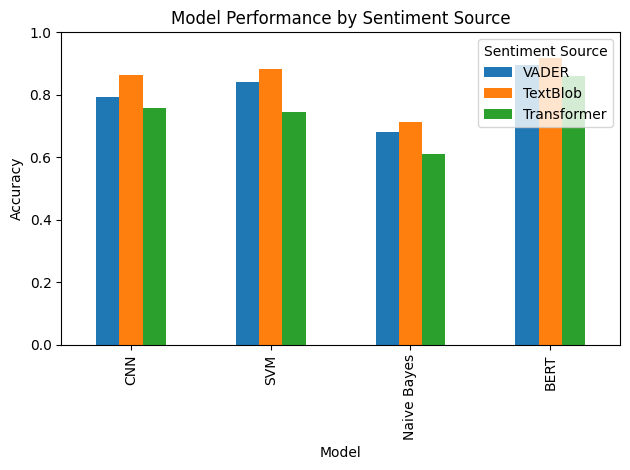

In [ ]:
ax = results_df.plot(kind='bar')
ax.set_title("Model Performance by Sentiment Source")
ax.set_xlabel("Model")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.0)
ax.legend(title="Sentiment Source", loc="best")
plt.tight_layout()
plt.show()

###### Let’s find out which model performed best for each sentiment source! This code checks the **highest accuracy** in each column and prints the **top-performing model** for **VADER**, **TextBlob**, and **Transformer** sentiment labelling.

In [ ]:
best_scores = results_df.idxmax()
print("Best models per sentiment source:")
print(best_scores)

Best models per sentiment source:
VADER          BERT
TextBlob       BERT
Transformer    BERT
dtype: object


###### Let’s create a **heatmap** to visualize model performance more clearly! Each cell shows the accuracy of **Naive Bayes**, **SVM**, **CNN**, and **BERT** across **VADER**, **TextBlob**, and **Transformer** labels, making it easy to spot the strongest results at a glance.

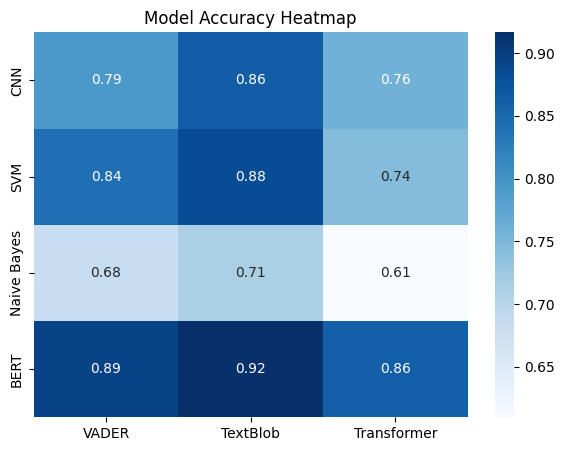

In [ ]:
plt.figure(figsize=(7,5))
sns.heatmap(results_df, annot=True, cmap="Blues", fmt=".2f")
plt.title("Model Accuracy Heatmap")
plt.show()

##### **Overall Labelling**

###### Let’s calculate the **average accuracy** for each sentiment source across all models. This helps us see whether **VADER**, **TextBlob**, or **Transformer** generally provided better training data for sentiment prediction overall.

In [ ]:
avg_scores = results_df.mean().sort_values(ascending=False)
print(avg_scores)

TextBlob       0.84390
VADER          0.80290
Transformer    0.74305
dtype: float64


###### Let’s visualize the **average accuracy** of each sentiment source across all models! This bar chart clearly shows whether **VADER**, **TextBlob**, or **Transformer** produced better overall results when used to train different sentiment classifiers.

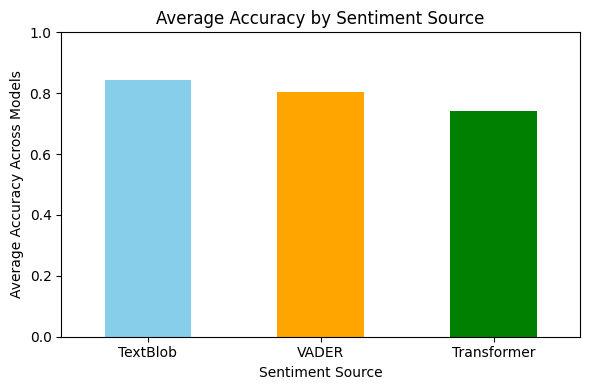

In [ ]:
plt.figure(figsize=(6,4))
avg_scores.plot(kind='bar', color=['skyblue', 'orange', 'green', 'red'])

plt.title('Average Accuracy by Sentiment Source')
plt.xlabel('Sentiment Source')
plt.ylabel('Average Accuracy Across Models')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

###### Let’s identify the **best overall sentiment source** This code finds which dataset **VADER**, **TextBlob**, or **Transformer** achieved the **highest average accuracy** across all models, then prints the top performer along with its exact score.

In [ ]:
best_source = avg_scores.idxmax()
best_score = avg_scores.max()
print(f"Best performing sentiment source: {best_source} ({best_score:.3f})")

Best performing sentiment source: TextBlob (0.844)


#### **For Model**

###### Let’s now check which **model** performed best on average across all sentiment sources. This code calculates the mean accuracy for each model  **Naive Bayes**, **SVM**, **CNN**, and **BERT** helping us see which one delivered the most consistent overall performance.

In [ ]:
avg_model_scores = results_df.mean(axis=1).sort_values(ascending=False)
print(avg_model_scores)

BERT           0.890167
SVM            0.823133
CNN            0.805033
Naive Bayes    0.668133
dtype: float64


###### Let’s visualize how each **model** performed on average across all sentiment sources! This bar chart compares the overall accuracy of **Naive Bayes**, **SVM**, **CNN**, and **BERT**, helping us easily see which model achieved the strongest and most reliable performance.

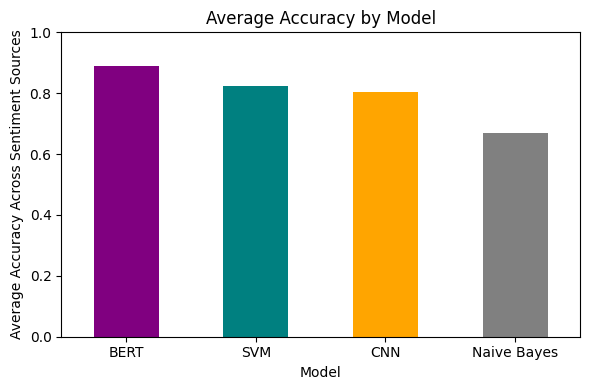

In [ ]:
plt.figure(figsize=(6,4))
avg_model_scores.plot(kind='bar', color=['purple', 'teal', 'orange', 'gray'])

plt.title('Average Accuracy by Model')
plt.xlabel('Model')
plt.ylabel('Average Accuracy Across Sentiment Sources')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

###### Let’s find out which **model** performed the best overall! This code identifies the model whether **Naive Bayes**, **SVM**, **CNN**, or **BERT** with the **highest average accuracy** across all sentiment sources and prints it along with its exact score.

In [ ]:
best_model = avg_model_scores.idxmax()
best_score = avg_model_scores.max()
print(f"Best performing model overall: {best_model} ({best_score:.3f})")

Best performing model overall: BERT (0.890)


###### Let’s save our cleaned and processed dataset! This line exports the entire **DataFrame** to a CSV file named **“Updated_Data.csv”**, excluding the index column, so we can easily reuse it for future analysis or modeling.

In [ ]:
Dataframe.to_csv('Updated_Data.csv', index=False)

#### Let save the result into JSOn file so we can use it later

In [ ]:
with open("model_results.json", "r") as f:
    data = json.load(f)

print(data)

{'2020': [{'Naive Bayes': [{'accuracy': 0.6849, 'precision': 0.7254, 'f1_score': 0.7022, 'use_class_weight': True, 'labels': 'vader_sentiment'}, {'accuracy': 0.609, 'precision': 0.6354, 'f1_score': 0.6131, 'use_class_weight': True, 'labels': 'sentiment'}, {'accuracy': 0.7092, 'precision': 0.7184, 'f1_score': 0.7123, 'use_class_weight': True, 'labels': 'Blob_Sentiment'}]}, {'SVM': [{'model_name': 'LinearSVC', 'use_class_weight': True, 'scores': [0.8061, 0.8094, 0.8077], 'labels': 'vader_sentiment'}, {'model_name': 'LinearSVC', 'use_class_weight': True, 'scores': [0.712, 0.7134, 0.7124], 'labels': 'sentiment'}, {'model_name': 'LinearSVC', 'use_class_weight': True, 'scores': [0.8294, 0.8303, 0.8297], 'labels': 'Blob_Sentiment'}, {'model_name': 'CNN', 'use_class_weight': True, 'scores': [0.7618, 0.7578, 0.7597], 'labels': 'vader_sentiment'}, {'model_name': 'CNN', 'use_class_weight': True, 'scores': [0.7418, 0.7339, 0.7361], 'labels': 'sentiment'}, {'model_name': 'CNN', 'use_class_weight': 

In [ ]:
data['2022'] = Result_global

with open("model_results.json", "w") as file:
    json.dump(data, file, indent=4)

print("Result Saved Successfully")

Result Saved Successfully


### **Topic Modelling**

###### Topic modelling helps uncover hidden themes in text data, like identifying key reasons behind employee concerns in a **job dissatisfaction** dataset.

#### **LDA - Latent Dirichlet Allocation**

#### **Loading the Dataset**

In [5]:
data = pd.read_csv('2022_JOB_Dissatisfaction_Sentiment.csv')

##### Displaying the datset to check if it's properly load

In [6]:
display(data)

,id,created_utc,year,subreddit,label,text_raw,text_clean,text_lemma,compound,vader_sentiment,...,Blob_Sentiment,neg,neu,pos,sentiment,all_agree,two_or_more_agree,vader_strength,textblob_strength,transformer_strength
0,rudclf,1641141388,2022,antiwork,Positive,I'm a UK civil servant. I get paid slightly a...,i'm a uk civil servant i get paid slightly abo...,I uk civil servant I get pay slightly average ...,0.9105,Positive,...,Positive,0.218057,0.098412,0.134666,Negative,False,False,0.9105,0.253750,0.218057
1,ruds1x,1641142598,2022,antiwork,Negative,"I started this job a few months ago, but it's ...",i started this job a few months ago but it's b...,I start job month ago hell handing resignation...,-0.0258,Neutral,...,Negative,0.027224,0.014839,0.680394,Positive,False,False,0.0258,0.012637,0.680394
2,ruo93e,1641170518,2022,antiwork,Negative,TLDR - Years ago managers gave terrible justif...,tldr years ago managers gave terrible justific...,tldr year ago manager give terrible justificat...,0.9976,Positive,...,Positive,0.093591,0.267444,0.345591,Positive,True,True,0.9976,0.132401,0.345591
3,rvlkeu,1641270518,2022,antiwork,Positive,I am filipino nurse working in the UK. I reall...,i am filipino nurse working in the uk i really...,I filipino nurse work uk I really love job lat...,0.9484,Positive,...,Negative,0.030945,0.012269,0.870931,Positive,False,False,0.9484,0.033333,0.870931
4,rvsqvs,1641297487,2022,antiwork,Negative,Seems like a counter intuitive question for th...,seems like a counter intuitive question for th...,seem like counter intuitive question sub unfor...,0.9677,Positive,...,Positive,0.231623,0.143911,0.064508,Negative,False,False,0.9677,0.032229,0.231623
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36035,ilx6d8q,1661548319,2022,WorkReform,Negative,&gt;Quiet quitting hasn't been mention in any ...,gt quiet quitting hasn't been mention in any o...,gt quiet quitting mention channel I follow wor...,0.6486,Positive,...,Positive,0.010554,0.897569,0.006386,Neutral,False,False,0.6486,0.019654,0.897569
36036,irfcebl,1665163442,2022,WorkReform,Negative,We don't have a free market for most of our he...,we don't have a free market for most of our he...,free market healthcare option exist like retai...,0.9720,Positive,...,Positive,0.008491,0.893223,0.005107,Neutral,False,False,0.9720,0.001937,0.893223
36037,izperip,1670706841,2022,WorkReform,Positive,You seem argumentative for no particular reaso...,you seem argumentative for no particular reaso...,seem argumentative particular reason skirt aro...,0.6415,Positive,...,Positive,0.039476,0.164111,0.014907,Negative,False,False,0.6415,0.080769,0.164111
36038,izph8c0,1670707857,2022,WorkReform,Positive,&gt; You're skirting around the point that the...,gt you're skirting around the point that the a...,gt skirt around point hypothetical make withou...,0.7592,Positive,...,Positive,0.027482,0.429378,0.008840,Negative,False,False,0.7592,0.048196,0.429378


#### **LDA**

##### Let's converts the lemmatized text into numerical feature vectors using the Bag-of-Words method, removes common English stopwords, and safely handles any missing values.

In [7]:
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(data['text_lemma'].fillna(''))

##### We are going to loop through different numbers of topics, train an LDA model for each one and calculate the perplexity score and plot the results to find the best number of topics.

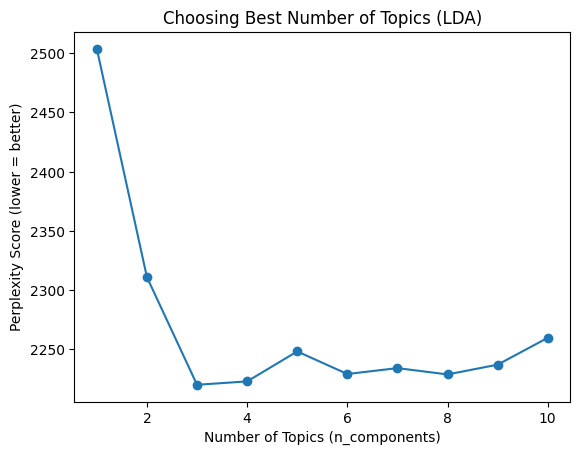

In [8]:
scores = []
topics = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

for n in topics:
    lda = LatentDirichletAllocation(n_components=n, random_state=42)
    lda.fit(X)
    score = lda.perplexity(X)
    scores.append(score)

plt.plot(topics, scores, marker='o')
plt.title("Choosing Best Number of Topics (LDA)")
plt.xlabel("Number of Topics (n_components)")
plt.ylabel("Perplexity Score (lower = better)")
plt.show()

##### Train the LDA model with 4 topics, then extract and display the top 10 most important words for each topic.

In [9]:
lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(X)

words = vectorizer.get_feature_names_out()
num_words = 10

for i, topic in enumerate(lda.components_):
    top_words = [words[j] for j in topic.argsort()[-num_words:]]
    print(f"Topic {i+1}: {', '.join(top_words)}")

Topic 1: minister, people, boris, government, tory, johnson, party, say, gt, resign
Topic 2: like, day, make, hour, time, year, people, pay, job, work
Topic 3: thing, make, say, unreasonable, time, think, people, like, bad, really


##### Get the topic probability distribution for each document in the dataset.

In [10]:
doc_topic_dist = lda.transform(X)

##### Assign each document to the topic with the highest probability.

In [11]:
data['topic_LDA'] = doc_topic_dist.argmax(axis=1)

##### Create and display a dictionary that assigns meaningful names to each LDA topic.

In [12]:
Topic_suggestion = {
    "Topic 1": "UK Government, Boris Johnson & Political Resignations",
    "Topic 2": "Daily Work Life, Pay & Working Hours",
    "Topic 3": "Public Frustration, Complaints & Unreasonable Situations"
}

print(Topic_suggestion)

{'Topic 1': 'UK Government, Boris Johnson & Political Resignations', 'Topic 2': 'Daily Work Life, Pay & Working Hours', 'Topic 3': 'Public Frustration, Complaints & Unreasonable Situations'}


##### Map each numeric topic to its descriptive name and add it as a new column in the dataset.

In [13]:
topic_label_map = {i: Topic_suggestion[f"Topic {i+1}"] for i in range(3)}
data['topic_label_LDA'] = data['topic_LDA'].map(topic_label_map)

##### Let's group the data by topic and sentiment, then count how many records fall into each group.

In [14]:
sentiment_summary = (
    data.groupby(['topic_label_LDA', 'sentiment'])
      .size()
      .reset_index(name='count')
)
display(sentiment_summary)

,topic_label_LDA,sentiment,count
0,"Daily Work Life, Pay & Working Hours",Negative,5157
1,"Daily Work Life, Pay & Working Hours",Neutral,7681
2,"Daily Work Life, Pay & Working Hours",Positive,3281
3,"Public Frustration, Complaints & Unreasonable ...",Negative,5355
4,"Public Frustration, Complaints & Unreasonable ...",Neutral,3830
5,"Public Frustration, Complaints & Unreasonable ...",Positive,2637
6,"UK Government, Boris Johnson & Political Resig...",Negative,2085
7,"UK Government, Boris Johnson & Political Resig...",Neutral,5302
8,"UK Government, Boris Johnson & Political Resig...",Positive,712


##### Let draw a chat to show the relationship among the two of them

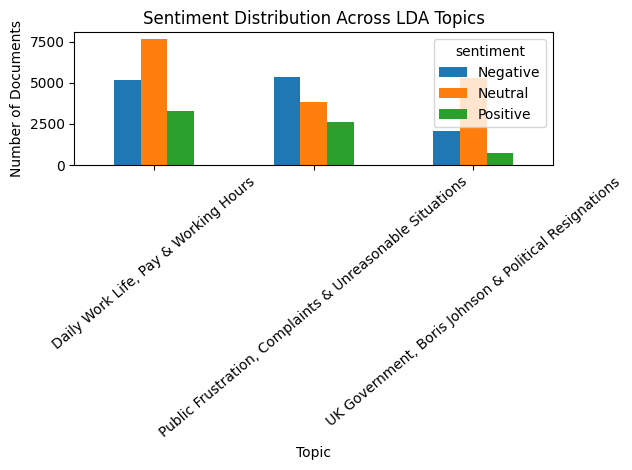

In [15]:
pivot_table = sentiment_summary.pivot(
    index='topic_label_LDA',
    columns='sentiment',
    values='count'
).fillna(0)

# Plot the bar chart
pivot_table.plot(kind='bar')

plt.title("Sentiment Distribution Across LDA Topics")
plt.xlabel("Topic")
plt.ylabel("Number of Documents")
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

#### **Create the Table**

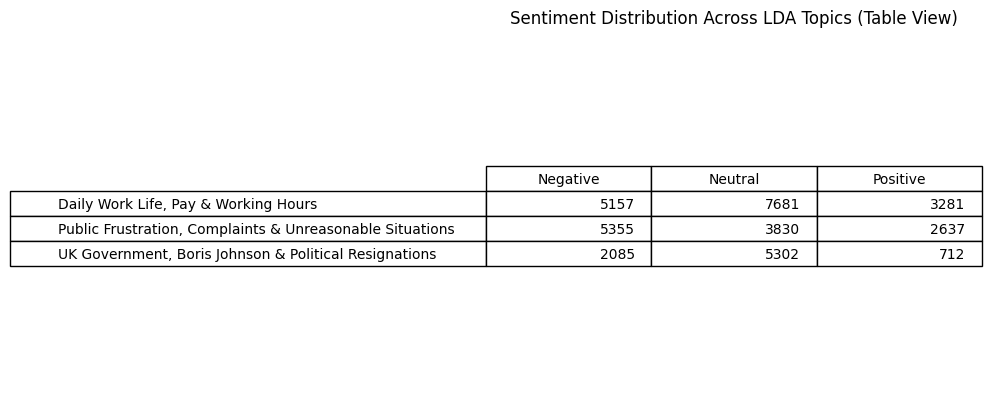

In [16]:
pivot_table = sentiment_summary.pivot(
    index='topic_label_LDA',
    columns='sentiment',
    values='count'
).fillna(0)

fig, ax = plt.subplots()
ax.axis('off')

table = ax.table(
    cellText=pivot_table.values,
    colLabels=pivot_table.columns,
    rowLabels=pivot_table.index,
    loc='center'
)

table.scale(1, 1.5)

plt.title("Sentiment Distribution Across LDA Topics (Table View)")
plt.show()

##### Let's build a Gensim LDA model and evaluate its topic quality using the coherence score.

In [27]:
corpus = [vectorizer.inverse_transform(x)[0] for x in X]
dictionary = Dictionary(corpus)

bow_corpus = [dictionary.doc2bow(doc) for doc in corpus]

lda_gensim = LdaModel(bow_corpus, num_topics=7, id2word=dictionary, passes=15, random_state=42)


coherence_model = CoherenceModel(model=lda_gensim, texts=corpus, dictionary=dictionary, coherence='c_v')
coherence_score = coherence_model.get_coherence()
print("Coherence Score:", coherence_score)

Coherence Score: 0.6848141674313818


In [28]:
lda_json = {}

for _, row in sentiment_summary.iterrows():
    topic = row["topic_label_LDA"]
    sentiment = row["sentiment"]
    count = int(row["count"])

    if topic not in lda_json:
        lda_json[topic] = {}

    lda_json[topic][sentiment] = count


final_lda_json = {
    "LDA_Sentiment_Summary": lda_json
}
print(final_lda_json)


{'LDA_Sentiment_Summary': {'Daily Work Life, Pay & Working Hours': {'Negative': 5157, 'Neutral': 7681, 'Positive': 3281}, 'Public Frustration, Complaints & Unreasonable Situations': {'Negative': 5355, 'Neutral': 3830, 'Positive': 2637}, 'UK Government, Boris Johnson & Political Resignations': {'Negative': 2085, 'Neutral': 5302, 'Positive': 712}}}


### **Bertopic**

##### BERTopic is a topic modeling technique that uses BERT embeddings to generate coherent and meaningful topics from large text datasets.

##### Download the list of common stopwords used for text preprocessing

In [29]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

##### Let's removes automated moderator messages using predefined text patterns and keeps only genuine user-generated content for analysis.

In [30]:
patterns_to_remove = [
    "thank posting",
    "please help keep",
    "welcoming",
    "moderators",
    "megathread",
    "submissionpost",
    "automatically",
    "contact the moderators",
    "if you have a concern",
    "replying submissionpost",
    "help us make better",
]


def remove_auto_mod(text):
    for p in patterns_to_remove:
        if p in text.lower():
            return None
    return text

data["filtered_text"] = data["text_raw"].apply(remove_auto_mod)
data = data.dropna(subset=["filtered_text"])
documents = data["filtered_text"].tolist()

##### Let's converts the cleaned text column into a list of documents for further analysis.

In [31]:
documents = data["filtered_text"].tolist()

##### Let's set up and runs a customized BERTopic pipeline using Sentence-BERT embeddings, CountVectorizer, UMAP for dimensionality reduction, and HDBSCAN for clustering to generate well-separated, fine-grained topics from the text documents.

In [32]:
embedding_model = SentenceTransformer("all-mpnet-base-v2")

vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=10
)

#UMAP – more separation, more topics
umap_model = UMAP(
    n_neighbors=5,
    n_components=15,
    min_dist=0.0,
    random_state=42
)

# HDBSCAN – allow smaller clusters
hdbscan_model = HDBSCAN(
    min_cluster_size=80,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

# BERTopic
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    min_topic_size=10,
    nr_topics=None
)

topics, probs = topic_model.fit_transform(documents)

#### Let retrieves a summary table of all discovered topics, including their sizes and labels.

In [41]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,8676,-1_work_people_just_job,"[work, people, just, job, time, don, like, gt,...","[&gt;Perhaps I should have started with, am HR..."
1,0,1958,0_nhs_nurses_doctors_staff,"[nhs, nurses, doctors, staff, patients, pay, n...",[This isn't a satisfying 'I quit my job and he...
2,1,886,1_notice_resignation_notice period_period,"[notice, resignation, notice period, period, c...","[Any company can waive your notice period, the..."
3,2,850,2_resign_pm_parliament_resigned,"[resign, pm, parliament, resigned, party, lead...",[Then he should resign as leader of the Conser...
4,3,838,3_job_degree_career_uni,"[job, degree, career, uni, work, life, years, ...","[Hello all,\n\nI currently work at a universit..."
...,...,...,...,...,...
87,86,89,86_week_day week_day_days,"[week, day week, day, days, work, work week, p...",[Most of the companies participating in a four...
88,87,85,87_underpaid_carers_undervalued_care,"[underpaid, carers, undervalued, care, workers...","[Care workers are underpaid, but that doesn't ..."
89,88,82,88_holiday_leave_days_annual leave,"[holiday, leave, days, annual leave, holidays,...",[Your comment is not making sense and missing ...
90,89,82,89_unreasonable_prices_costs_price,"[unreasonable, prices, costs, price, cost, qui...",[noon 16 Jan to 1pm 23 Jan: 7 days work/lodgin...


In [46]:
topic_info = topic_model.get_topic_info()

top_10_topics = topic_info.head(10)

display(top_10_topics)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,8676,-1_work_people_just_job,"[work, people, just, job, time, don, like, gt,...","[&gt;Perhaps I should have started with, am HR..."
1,0,1958,0_nhs_nurses_doctors_staff,"[nhs, nurses, doctors, staff, patients, pay, n...",[This isn't a satisfying 'I quit my job and he...
2,1,886,1_notice_resignation_notice period_period,"[notice, resignation, notice period, period, c...","[Any company can waive your notice period, the..."
3,2,850,2_resign_pm_parliament_resigned,"[resign, pm, parliament, resigned, party, lead...",[Then he should resign as leader of the Conser...
4,3,838,3_job_degree_career_uni,"[job, degree, career, uni, work, life, years, ...","[Hello all,\n\nI currently work at a universit..."
5,4,792,4_energy_water_gas_really bad,"[energy, water, gas, really bad, bad, heat, re...",[Today I had an old builder come over of my da...
6,5,722,5_boris_resign_party_pm,"[boris, resign, party, pm, resigned, resigning...",[I think when Rishi resigned her either:\n\n- ...
7,6,694,6_resign_resigned_resigning_resignation,"[resign, resigned, resigning, resignation, won...","[“Resign 🥰” is the best one, Then he should re..."
8,7,660,7_food_eat_meat_bad,"[food, eat, meat, bad, eating, really bad, rea...",[&gt;Because food is such a bigger part of the...
9,8,628,8_teachers_teaching_teacher_school,"[teachers, teaching, teacher, school, students...","[I'm really upset at the idea, but because I t..."


#### Let extracts the top keywords for each topic and stores them in a dictionary for easy access and analysis.

In [42]:
topics_dict = topic_model.get_topics()

topic_words = {}

for topic_id, words in topics_dict.items():
    topic_words[topic_id] = [w for w, _ in words]

#### Let tokenizes each document by splitting it into a list of individual words.

In [43]:
texts = [doc.split() for doc in documents]

##### This line creates a Gensim dictionary that maps each unique word in the documents to a numerical ID.

In [44]:
dictionary = Dictionary(texts)

##### Let calculates the coherence score for each topic using only valid words from the dictionary, helping to evaluate how meaningful and consistent each topic is.

In [40]:
topic_coherence = {}

for topic_id, words_list in topic_words.items():
    filtered_words = [word for word in words_list if word in dictionary.token2id]

    if filtered_words:
        cm = CoherenceModel(
            topics=[filtered_words],
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )
        topic_coherence[topic_id] = cm.get_coherence()
    else:
        topic_coherence[topic_id] = None

##### Let's converts the topic coherence scores into a DataFrame, sorts them in descending order, and displays the top 15 most coherent topics.

In [38]:
df_coh = pd.DataFrame({
    "topic": list(topic_coherence.keys()),
    "coherence": list(topic_coherence.values())
})

df_coh_sorted = df_coh.sort_values("coherence", ascending=False)
df_coh_sorted.head(15)

,topic,coherence
22,21,0.875275
29,28,0.820193
9,8,0.796217
65,64,0.783276
49,48,0.774613
34,33,0.771448
43,42,0.760991
27,26,0.749851
35,34,0.735650
32,31,0.732458


#### Calculate overall coherence using the filtered topic words

In [39]:
filtered_global_topic_words = []
for topic_id, words_list in topic_words.items():
    filtered_words = [word for word in words_list if word in dictionary.token2id]
    if filtered_words:
        filtered_global_topic_words.append(filtered_words)
cm_global = CoherenceModel(
    topics=filtered_global_topic_words,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
)

overall_coherence = cm_global.get_coherence()
print("Overall coherence:", overall_coherence)

Overall coherence: 0.5404424046068312


##### This code assigns meaningful, human-readable labels to selected topics to improve the interpretability of the BERTopic model results.

In [47]:
topic_labels = {
    -1: "General Work & Public Discussion",
    0: "NHS Staff, Nurses & Doctors Pay Crisis",
    1: "Notice Periods & Resignation Rules at Work",
    2: "Prime Minister, Parliament & Political Resignations",
    3: "Careers, Degrees & University-to-Job Pathways",
    4: "Energy, Gas & Household Utility Cost Crisis",
    5: "Boris Johnson, Party Leadership & Resignations",
    6: "Public Calls for Resignation & Political Scandals",
    7: "Food Prices, Diet & Cost of Living Pressures",
    8: "Teachers, Schools & Education Workforce Crisis"
}

topic_model.set_topic_labels(topic_labels)

##### This displays the top 10 topics along with their updated labels, sizes, and key information after topic labeling.

In [48]:
topic_model.get_topic_info().head(10)

,Topic,Count,Name,CustomName,Representation,Representative_Docs
0,-1,8676,-1_work_people_just_job,General Work & Public Discussion,"[work, people, just, job, time, don, like, gt,...","[&gt;Perhaps I should have started with, am HR..."
1,0,1958,0_nhs_nurses_doctors_staff,"NHS Staff, Nurses & Doctors Pay Crisis","[nhs, nurses, doctors, staff, patients, pay, n...",[This isn't a satisfying 'I quit my job and he...
2,1,886,1_notice_resignation_notice period_period,Notice Periods & Resignation Rules at Work,"[notice, resignation, notice period, period, c...","[Any company can waive your notice period, the..."
3,2,850,2_resign_pm_parliament_resigned,"Prime Minister, Parliament & Political Resigna...","[resign, pm, parliament, resigned, party, lead...",[Then he should resign as leader of the Conser...
4,3,838,3_job_degree_career_uni,"Careers, Degrees & University-to-Job Pathways","[job, degree, career, uni, work, life, years, ...","[Hello all,\n\nI currently work at a universit..."
5,4,792,4_energy_water_gas_really bad,"Energy, Gas & Household Utility Cost Crisis","[energy, water, gas, really bad, bad, heat, re...",[Today I had an old builder come over of my da...
6,5,722,5_boris_resign_party_pm,"Boris Johnson, Party Leadership & Resignations","[boris, resign, party, pm, resigned, resigning...",[I think when Rishi resigned her either:\n\n- ...
7,6,694,6_resign_resigned_resigning_resignation,Public Calls for Resignation & Political Scandals,"[resign, resigned, resigning, resignation, won...","[“Resign 🥰” is the best one, Then he should re..."
8,7,660,7_food_eat_meat_bad,"Food Prices, Diet & Cost of Living Pressures","[food, eat, meat, bad, eating, really bad, rea...",[&gt;Because food is such a bigger part of the...
9,8,628,8_teachers_teaching_teacher_school,"Teachers, Schools & Education Workforce Crisis","[teachers, teaching, teacher, school, students...","[I'm really upset at the idea, but because I t..."


#### Merging the topic with sentiment and drawing a chart

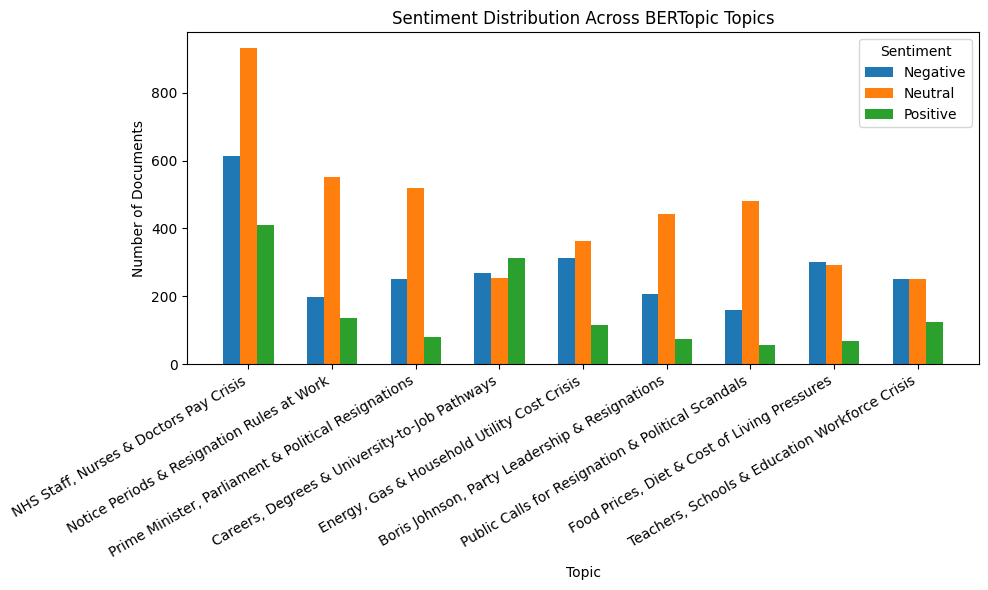

In [49]:
data = data.reset_index(drop=True)

data["topic_id"] = topics
data["topic_label"] = data["topic_id"].map(topic_labels)

data_plot = data[data["topic_id"] != -1].copy()

sent_counts = (
    data_plot.groupby(["topic_label", "sentiment"])
             .size()
             .reset_index(name="count")
)

sent_pivot = sent_counts.pivot(
    index="topic_label",
    columns="sentiment",
    values="count"
).fillna(0)

topic_order_df = (
    data_plot[["topic_id", "topic_label"]]
    .drop_duplicates()
    .sort_values("topic_id")
)

topic_order_df = topic_order_df.dropna(subset=['topic_label'])
sent_pivot = sent_pivot.loc[topic_order_df["topic_label"]]

topics_list = sent_pivot.index.tolist()
sentiments = sent_pivot.columns.tolist()

x = np.arange(len(topics_list))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

for i, s in enumerate(sentiments):
    ax.bar(
        x + (i - (len(sentiments)-1)/2) * width,
        sent_pivot[s].values,
        width,
        label=s
    )

ax.set_xticks(x)
ax.set_xticklabels(topics_list, rotation=30, ha="right")
ax.set_ylabel("Number of Documents")
ax.set_xlabel("Topic")
ax.set_title("Sentiment Distribution Across BERTopic Topics")
ax.legend(title="Sentiment")

plt.tight_layout()
plt.show()

#### Creating a JSON File to get the topic

In [50]:
bertopic_json = {}

for topic_id, words in topic_words.items():

    if topic_id not in data["topic_id"].values:
        continue
    topic_name = topic_labels.get(topic_id, f"Topic {topic_id}")
    doc_count = int((data["topic_id"] == topic_id).sum())
    coherence_score = topic_coherence.get(topic_id)
    sentiment_dist = (
        data[data["topic_id"] == topic_id]["sentiment"]
        .value_counts()
        .to_dict()
    )
    bertopic_json[f"topic_{topic_id}"] = {
        "topic_id": int(topic_id),
        "topic_label": topic_name,
        "top_words": words[:10],
        "document_count": doc_count,
        "coherence_score": coherence_score,
        "sentiment_distribution": sentiment_dist
    }

final_json = {
    "Bertopic": bertopic_json
}

print(final_json)

{'Bertopic': {'topic_-1': {'topic_id': -1, 'topic_label': 'General Work & Public Discussion', 'top_words': ['work', 'people', 'just', 'job', 'time', 'don', 'like', 'gt', 'really', 'pay'], 'document_count': 8676, 'coherence_score': np.float64(0.37628552109638186), 'sentiment_distribution': {'Neutral': 4115, 'Negative': 3065, 'Positive': 1496}}, 'topic_0': {'topic_id': 0, 'topic_label': 'NHS Staff, Nurses & Doctors Pay Crisis', 'top_words': ['nhs', 'nurses', 'doctors', 'staff', 'patients', 'pay', 'nurse', 'gp', 'care', 'patient'], 'document_count': 1958, 'coherence_score': np.float64(0.7133614703884927), 'sentiment_distribution': {'Neutral': 932, 'Negative': 615, 'Positive': 411}}, 'topic_1': {'topic_id': 1, 'topic_label': 'Notice Periods & Resignation Rules at Work', 'top_words': ['notice', 'resignation', 'notice period', 'period', 'contract', 'resign', 'letter', 'employer', 'resigning', 'company'], 'document_count': 886, 'coherence_score': np.float64(0.6080215755942795), 'sentiment_dis

#### Collapse Both LDA and Bertopic result for later exploration

In [55]:
data_final =  {
    "2022": {
        "LDA": final_lda_json,
        "Bertopic": final_json
    }
}

print(data_final)

{'2022': {'LDA': {'LDA_Sentiment_Summary': {'Daily Work Life, Pay & Working Hours': {'Negative': 5157, 'Neutral': 7681, 'Positive': 3281}, 'Public Frustration, Complaints & Unreasonable Situations': {'Negative': 5355, 'Neutral': 3830, 'Positive': 2637}, 'UK Government, Boris Johnson & Political Resignations': {'Negative': 2085, 'Neutral': 5302, 'Positive': 712}}}, 'Bertopic': {'Bertopic': {'topic_-1': {'topic_id': -1, 'topic_label': 'General Work & Public Discussion', 'top_words': ['work', 'people', 'just', 'job', 'time', 'don', 'like', 'gt', 'really', 'pay'], 'document_count': 8676, 'coherence_score': np.float64(0.37628552109638186), 'sentiment_distribution': {'Neutral': 4115, 'Negative': 3065, 'Positive': 1496}}, 'topic_0': {'topic_id': 0, 'topic_label': 'NHS Staff, Nurses & Doctors Pay Crisis', 'top_words': ['nhs', 'nurses', 'doctors', 'staff', 'patients', 'pay', 'nurse', 'gp', 'care', 'patient'], 'document_count': 1958, 'coherence_score': np.float64(0.7133614703884927), 'sentiment_

In [58]:
with open("2022_topic_model_master.json", "w", encoding="utf-8") as f:
    json.dump(data_final, f, indent=4, ensure_ascii=False)

print("Master JSON saved as topic_model_master.json")

Master JSON saved as topic_model_master.json
